# Machine Learning Group Assignment – Hotel Booking Cancellation

**Reference structure:** This notebook follows the same ML concepts and workflow used in the reference Financial Loan assignment: dataset overview, descriptive statistics, frequency distributions, missing-value analysis, outlier detection, correlation analysis, relationship analysis, feature engineering, one-hot encoding, standard scaling, SMOTE, feature selection/multicollinearity assessment, Logistic Regression, Decision Tree, Random Forest, confusion matrix, Accuracy, Precision, Recall, F1 Score, ROC-AUC, feature interpretation and model comparison.

**Dataset:** `hotel_bookings.csv`
**Target:** `is_canceled` (0 = Not Canceled, 1 = Canceled)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# The CSV is read from Google Drive, not uploaded directly to Colab.
# The code searches MyDrive for hotel_bookings.csv so the folder name does not have to be changed.
matches = glob.glob('/content/drive/MyDrive/ML/hotel_bookings.csv', recursive=True)
if len(matches) == 0:
    raise FileNotFoundError(
        'hotel_bookings.csv was not found in Google Drive. Place the file in My Drive and run this cell again.'
    )

DATA_PATH = matches[0]
print('Data file used:', DATA_PATH)
df = pd.read_csv(DATA_PATH)
display(df.head())

Data file used: /content/drive/MyDrive/ML/hotel_bookings.csv


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 1. Dataset Analysis

In [5]:
print(f'Dataset Shape: {df.shape}')
print('\nColumn Names:')
print(df.columns.tolist())

Dataset Shape: (119390, 32)

Column Names:
['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']


In [6]:
# Variable summary, similar to the reference assignment
summary_df = pd.DataFrame({
    'Variable Name': df.columns,
    'Variable Type': df.dtypes.values,
    'Missing Values': df.isnull().sum().values,
    'Missing Value %': (df.isnull().sum() / len(df) * 100).round(2).values
})

target_variable = 'is_canceled'
numerical_vars = df.select_dtypes(include=np.number).columns.tolist()
categorical_vars = df.select_dtypes(include=['object', 'category']).columns.tolist()

summary_df['Role'] = 'Other'
summary_df.loc[summary_df['Variable Name'] == target_variable, 'Role'] = 'Target'
summary_df.loc[summary_df['Variable Name'].isin(numerical_vars) & (summary_df['Variable Name'] != target_variable), 'Role'] = 'Numerical Feature'
summary_df.loc[summary_df['Variable Name'].isin(categorical_vars), 'Role'] = 'Categorical Feature'

display(summary_df)
print('\nNumerical variables:', numerical_vars)
print('Categorical variables:', categorical_vars)

,Variable Name,Variable Type,Missing Values,Missing Value %,Role
0,hotel,object,0,0.00,Categorical Feature
1,is_canceled,int64,0,0.00,Target
2,lead_time,int64,0,0.00,Numerical Feature
3,arrival_date_year,int64,0,0.00,Numerical Feature
4,arrival_date_month,object,0,0.00,Categorical Feature
5,arrival_date_week_number,int64,0,0.00,Numerical Feature
6,arrival_date_day_of_month,int64,0,0.00,Numerical Feature
7,stays_in_weekend_nights,int64,0,0.00,Numerical Feature
8,stays_in_week_nights,int64,0,0.00,Numerical Feature
9,adults,int64,0,0.00,Numerical Feature



Numerical variables: ['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']
Categorical variables: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']


## 2. Target Variable

Target variable: is_canceled

Target frequency:


,Frequency
is_canceled,
0,75166
1,44224



Target percentage distribution:


,Percentage
is_canceled,
0,62.96
1,37.04


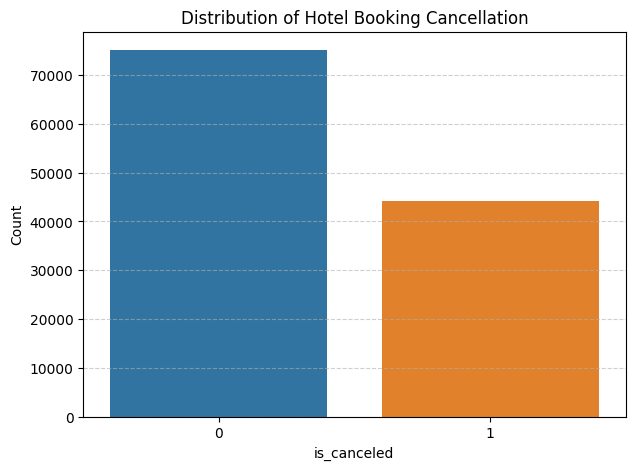

In [7]:
print('Target variable:', target_variable)
print('\nTarget frequency:')
display(df[target_variable].value_counts().to_frame('Frequency'))
print('\nTarget percentage distribution:')
display((df[target_variable].value_counts(normalize=True) * 100).round(2).to_frame('Percentage'))

plt.figure(figsize=(7,5))
sns.countplot(data=df, x=target_variable, hue=target_variable, legend=False)
plt.title('Distribution of Hotel Booking Cancellation')
plt.xlabel('is_canceled')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

## 3. Descriptive Statistics for Numerical Variables

In [8]:
numerical_vars = df.select_dtypes(include=np.number).columns.tolist()
descriptive_stats = df[numerical_vars].describe().T
descriptive_stats['median'] = df[numerical_vars].median()
descriptive_stats = descriptive_stats[['count','mean','median','std','min','25%','50%','75%','max']]
display(descriptive_stats)

,count,mean,median,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.000,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,69.000,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,2016.000,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,28.000,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,16.000,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,1.000,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,2.000,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,2.000,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.000,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.000,0.097436,0.00,0.00,0.000,0.0,10.0


## 4. Visualizing Numerical Variables

### Variable: is_canceled


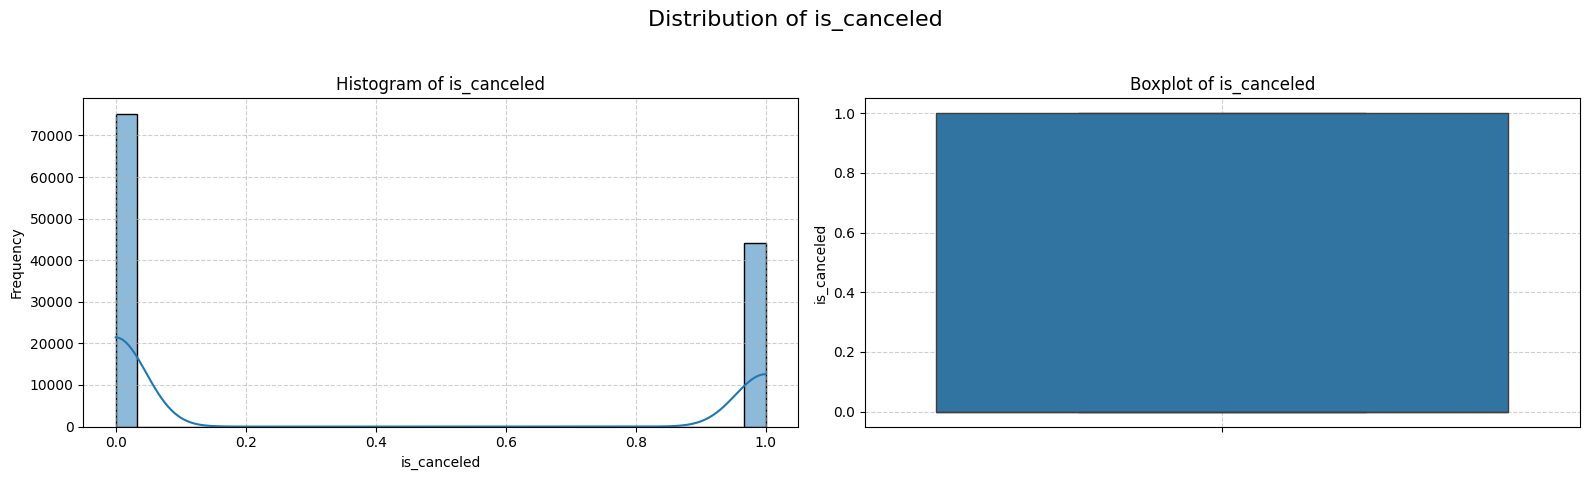

### Variable: lead_time


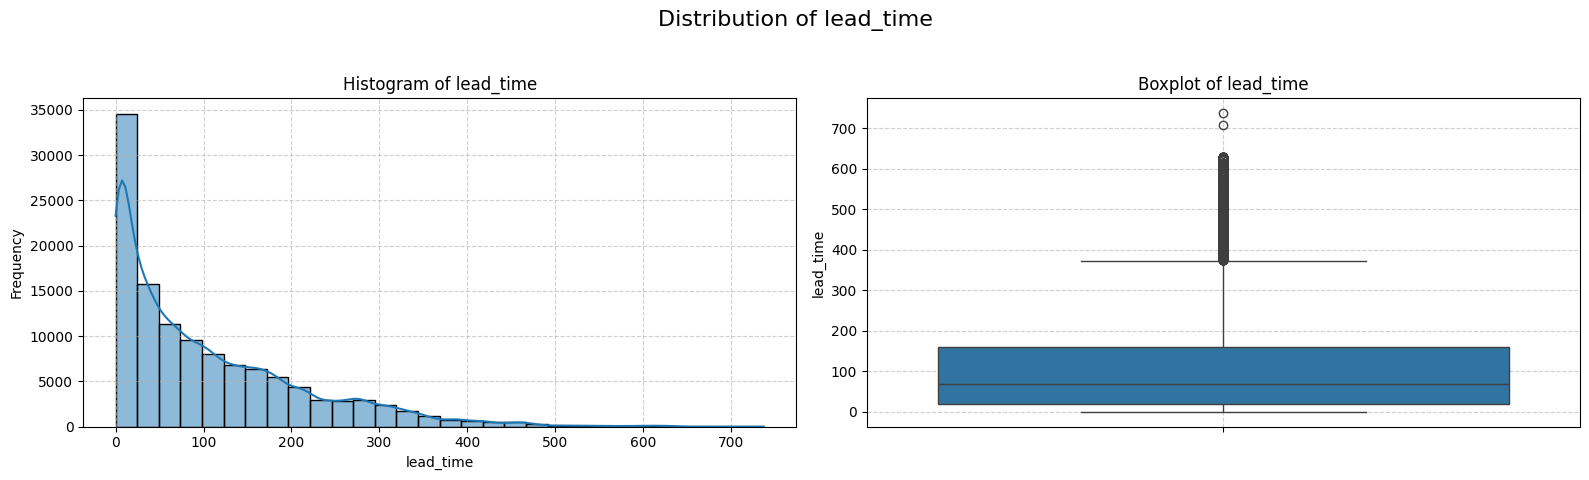

### Variable: arrival_date_year


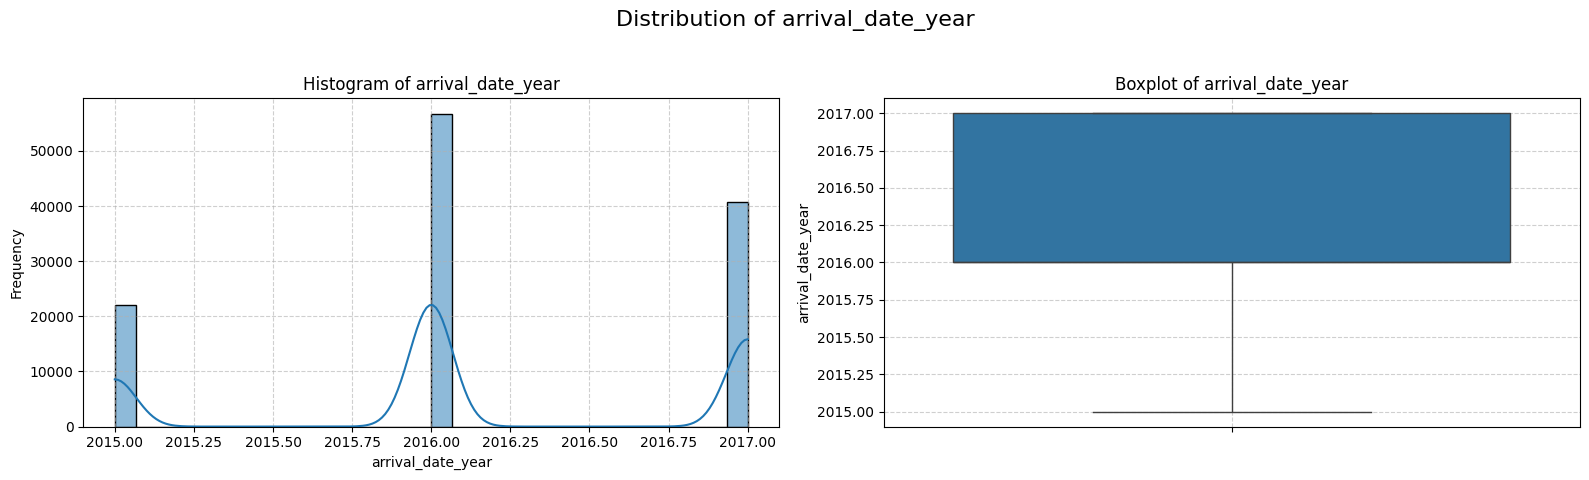

### Variable: arrival_date_week_number


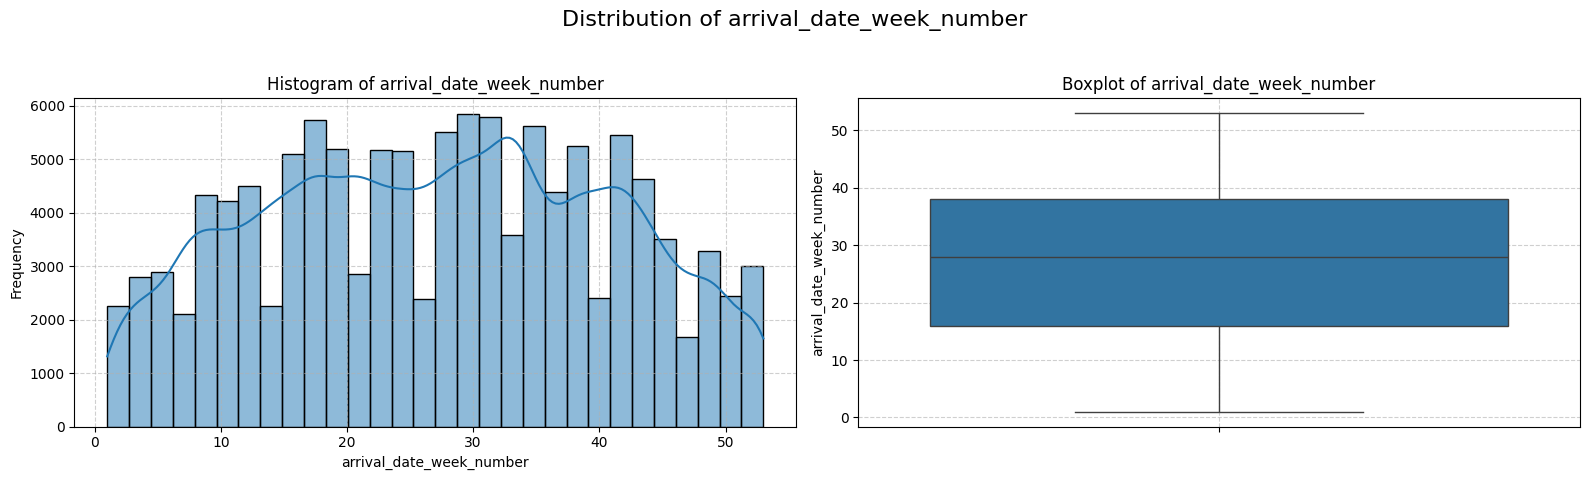

### Variable: arrival_date_day_of_month


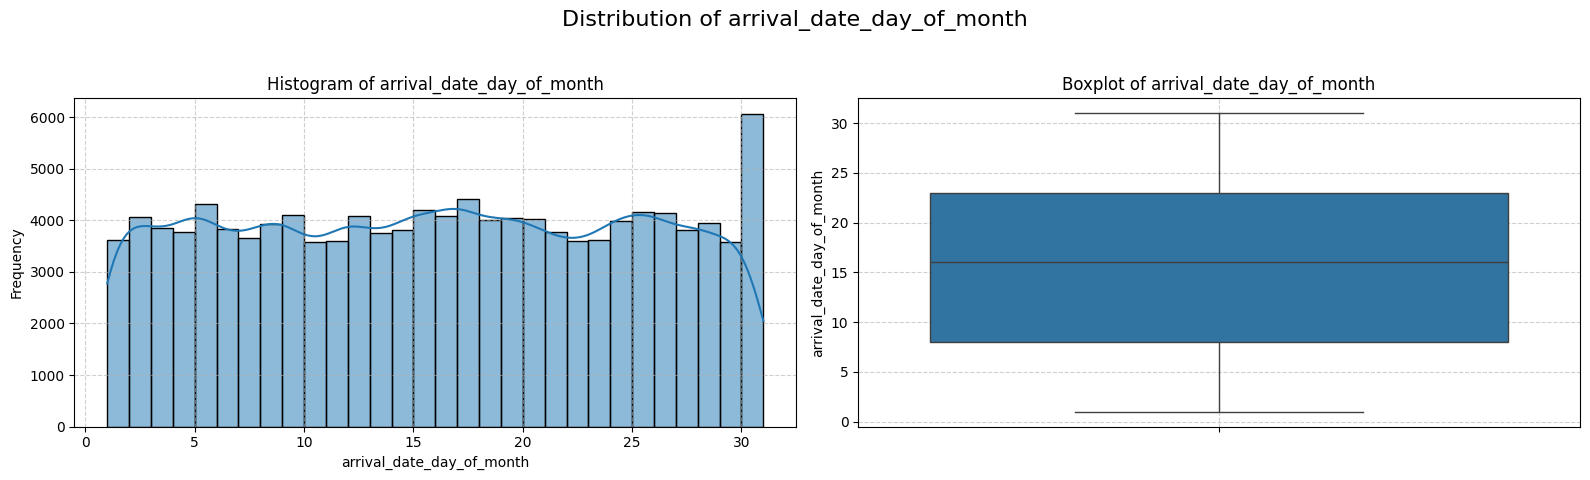

### Variable: stays_in_weekend_nights


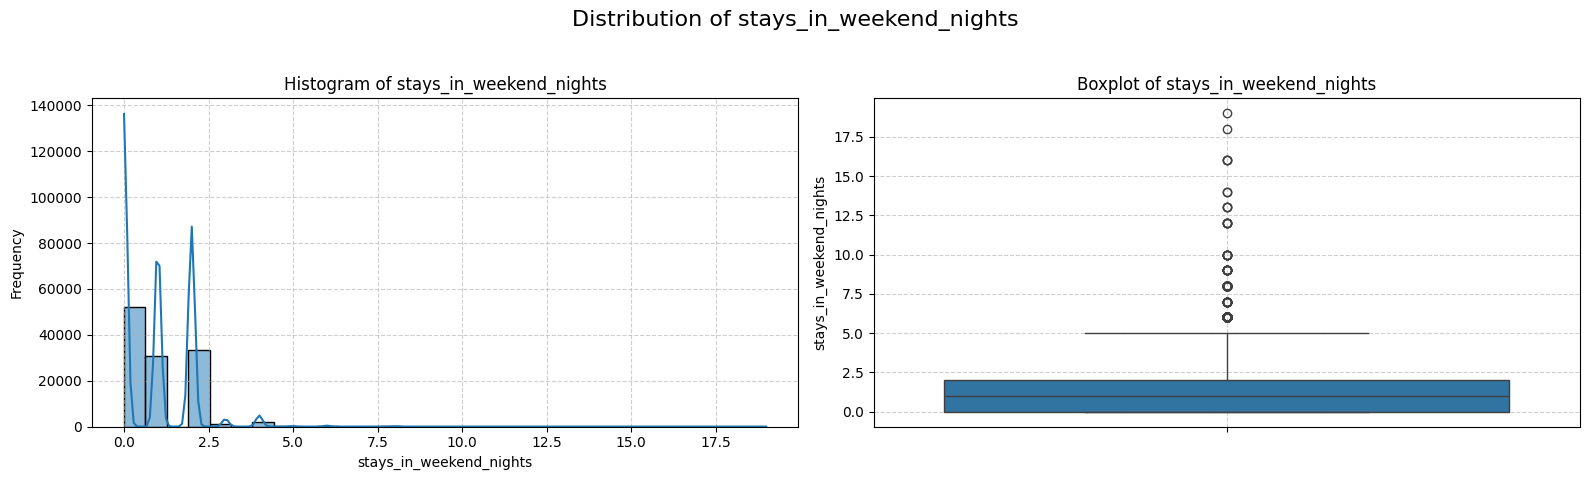

### Variable: stays_in_week_nights


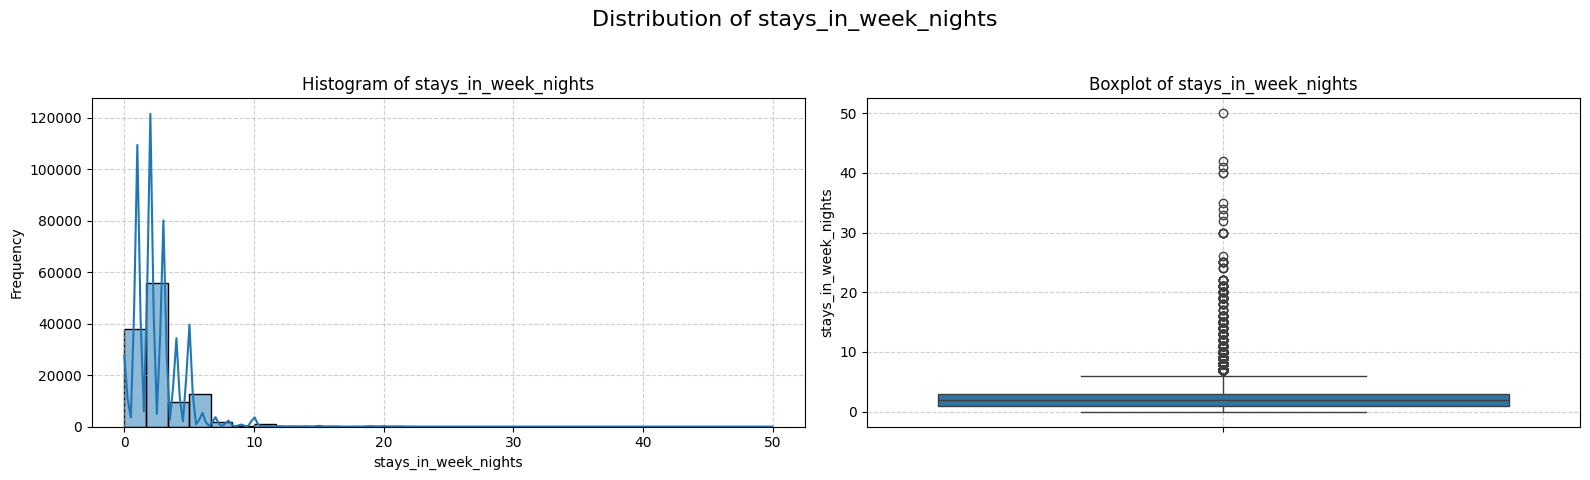

### Variable: adults


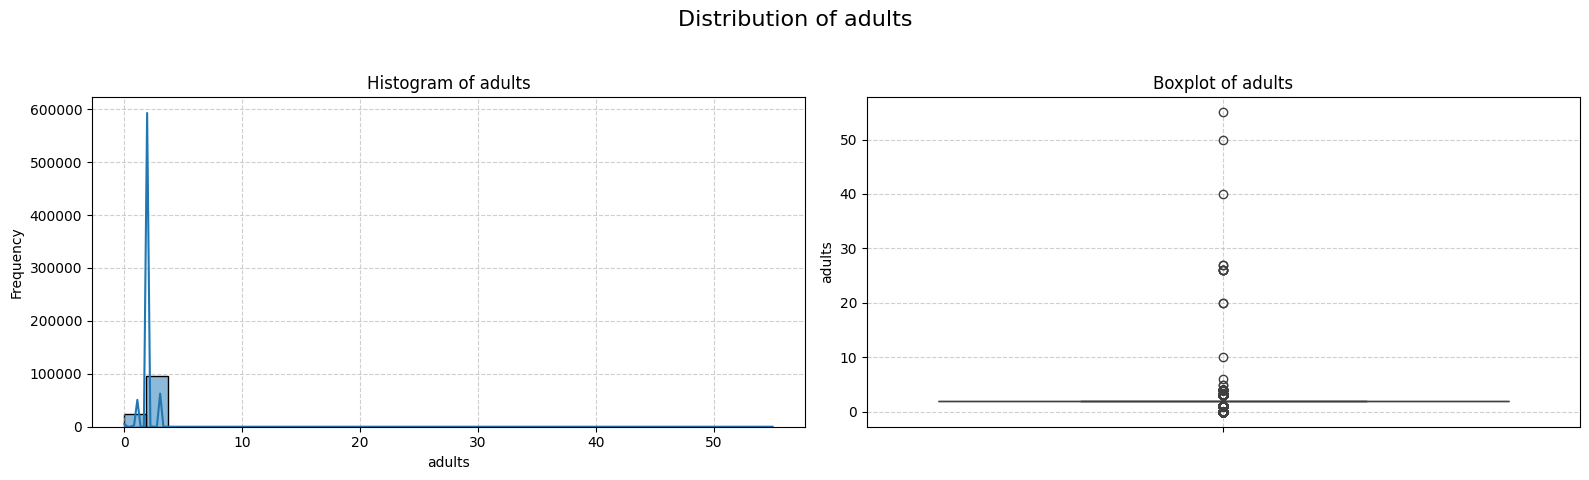

### Variable: children


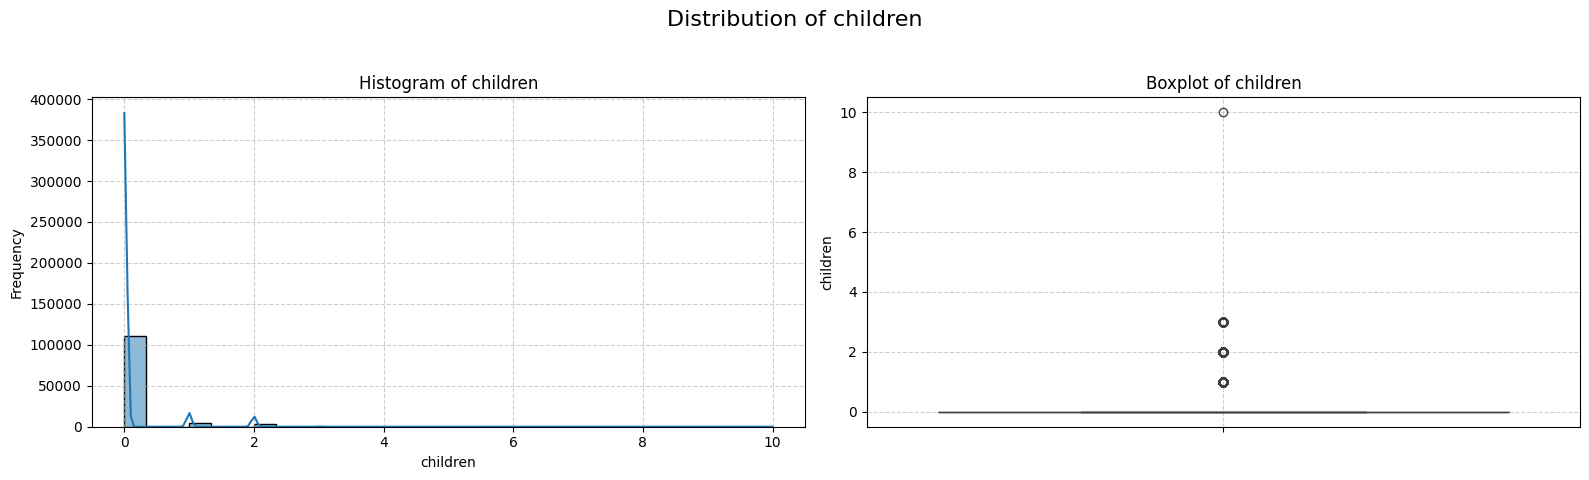

### Variable: babies


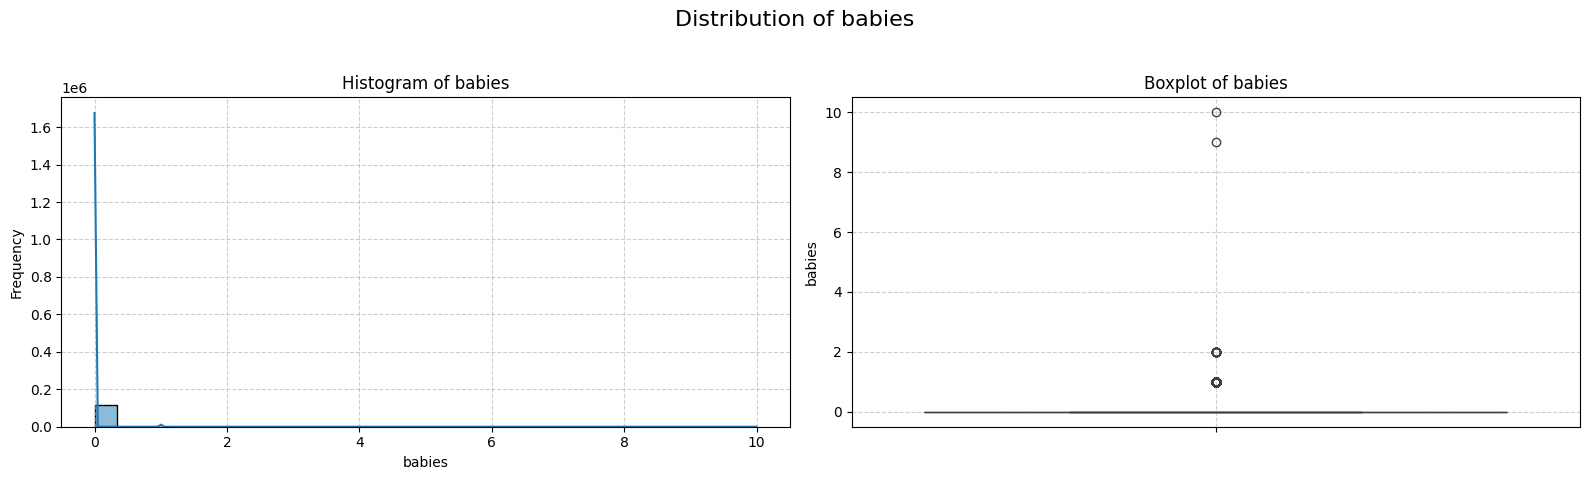

### Variable: is_repeated_guest


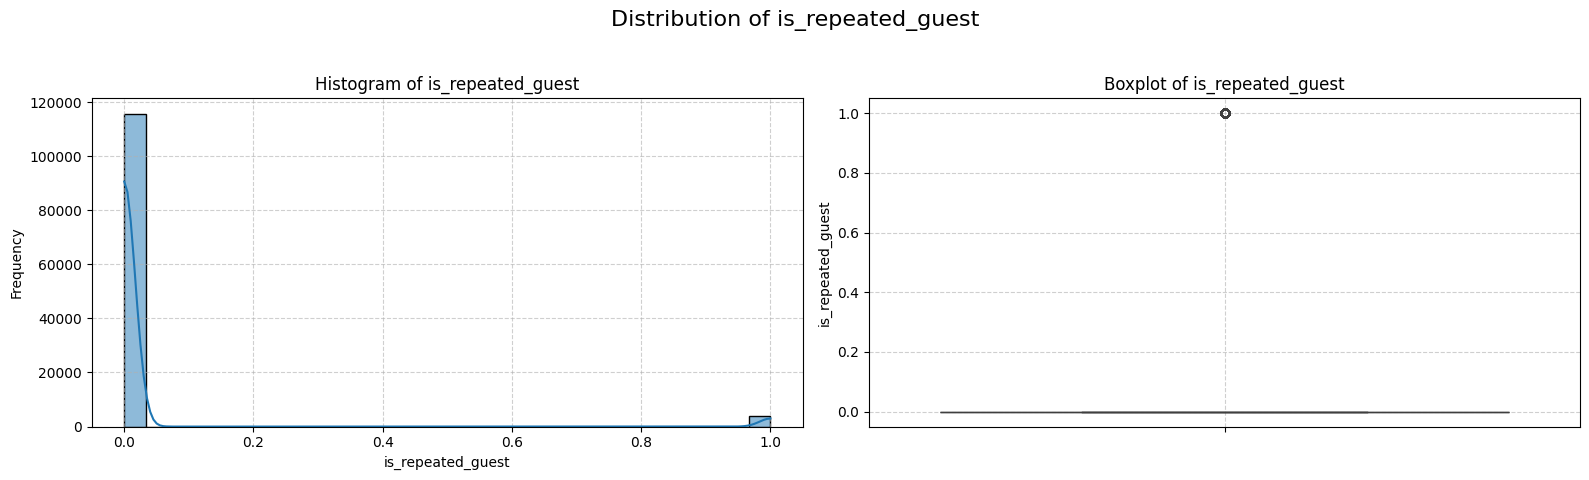

### Variable: previous_cancellations


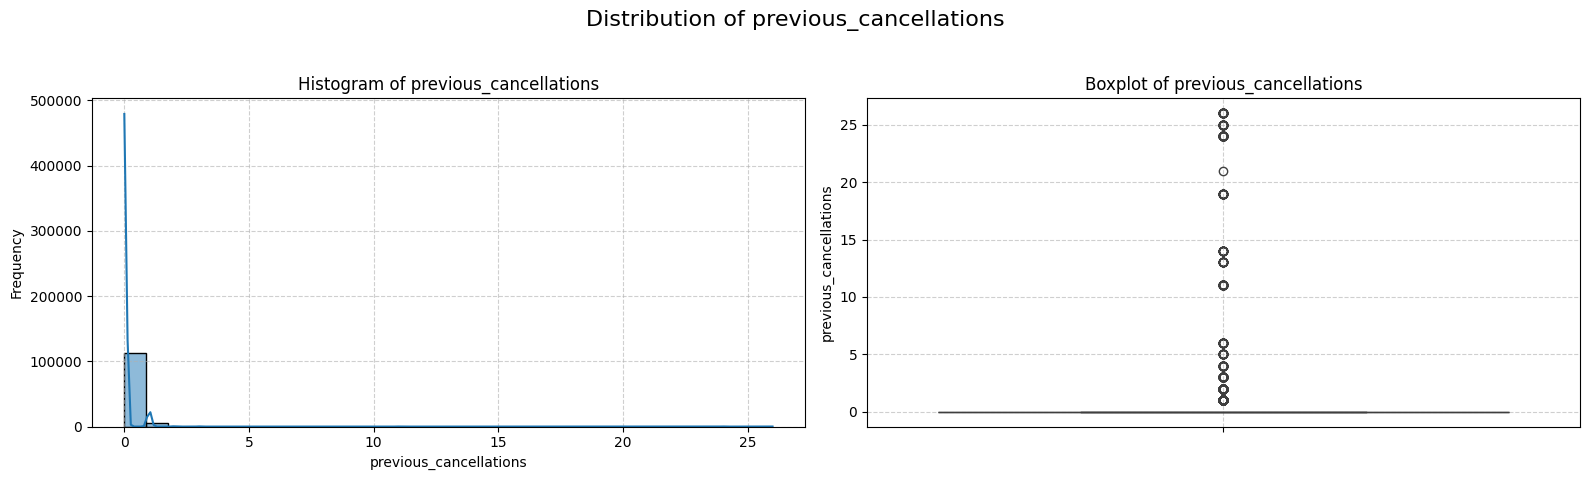

### Variable: previous_bookings_not_canceled


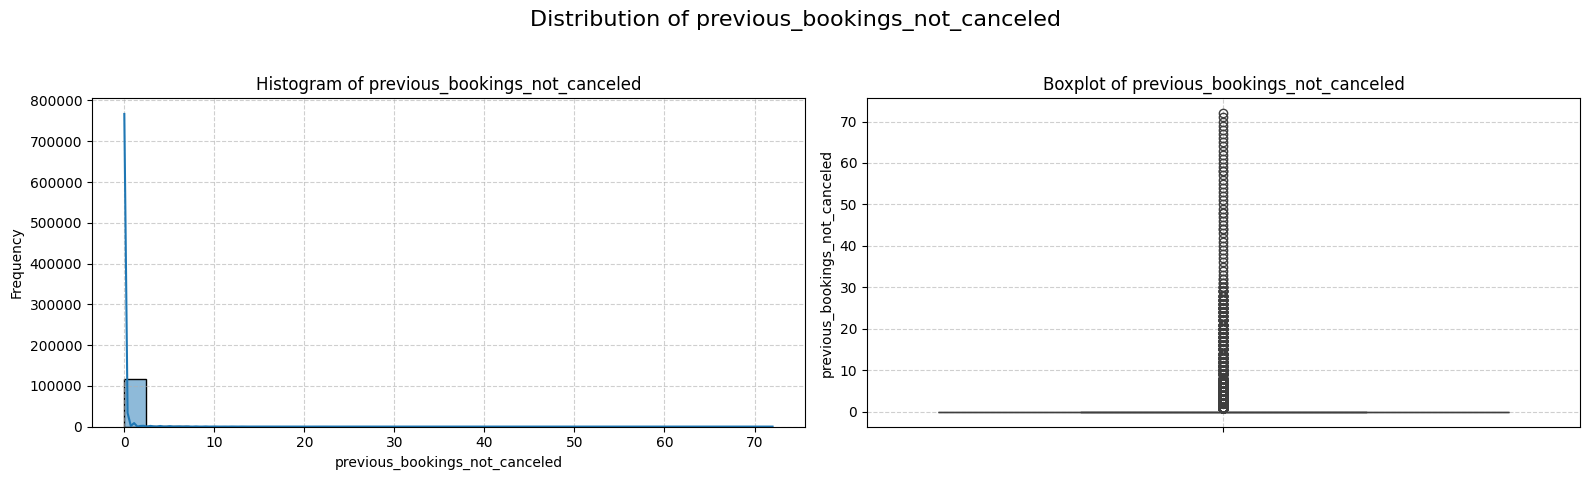

### Variable: booking_changes


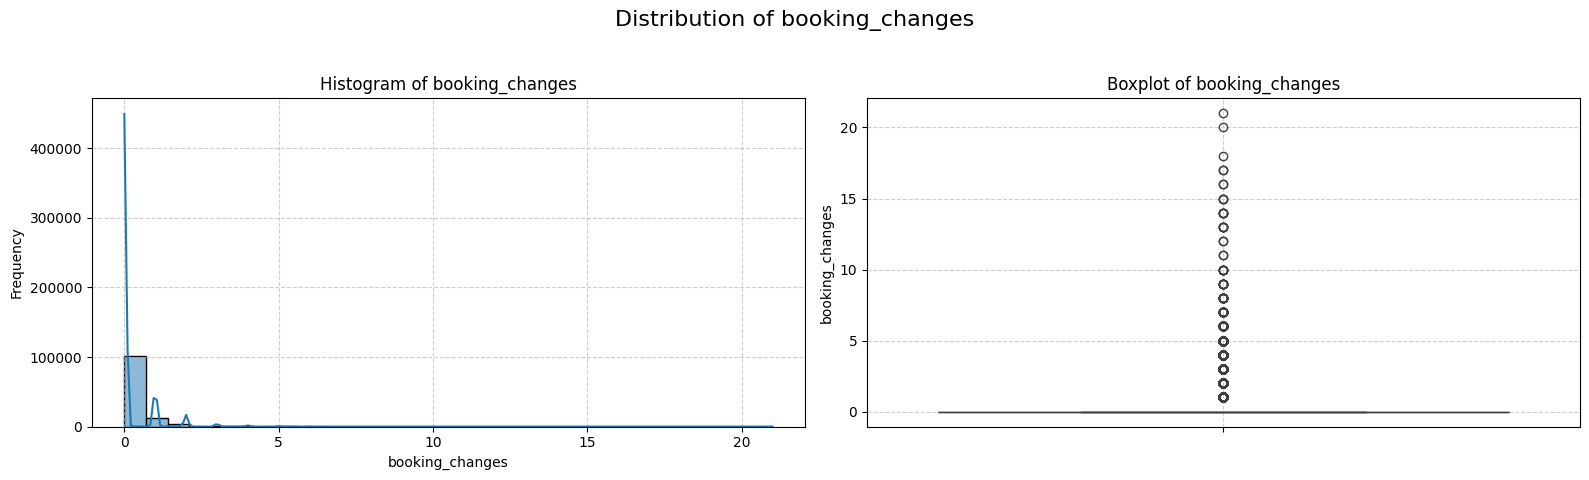

### Variable: agent


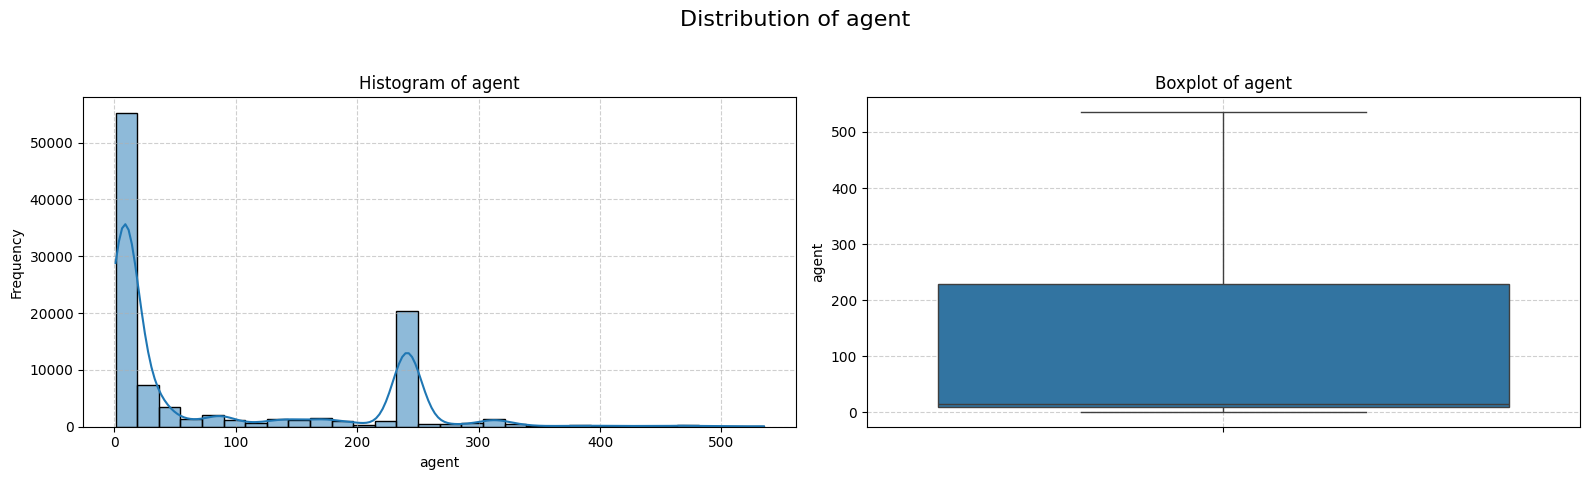

### Variable: company


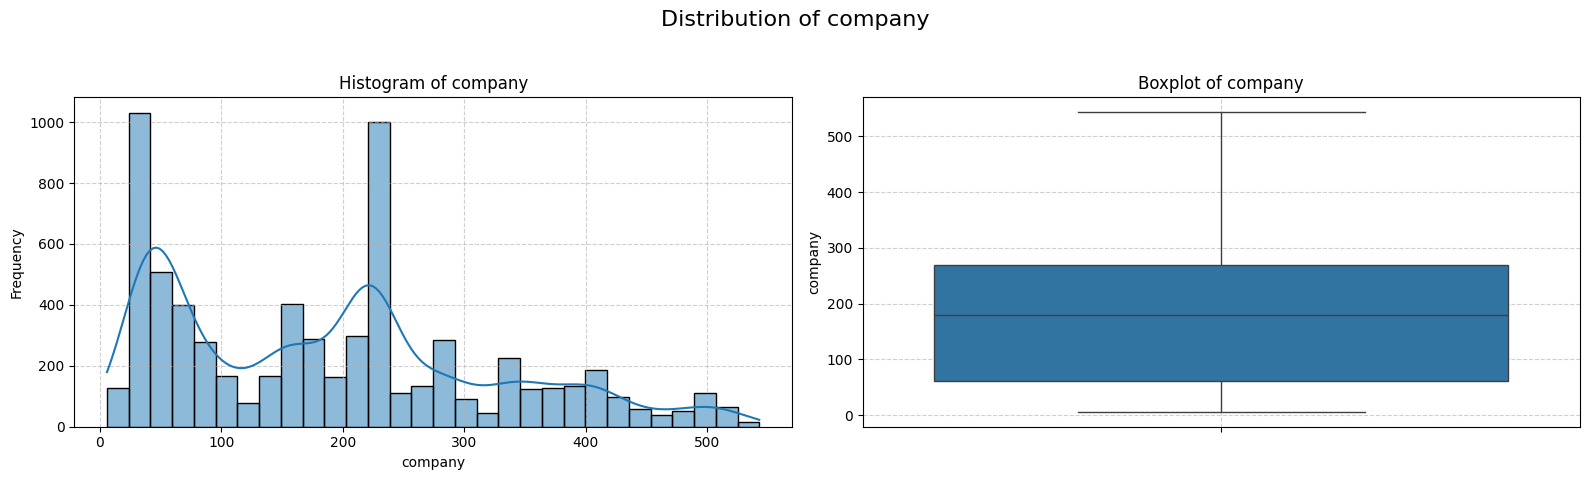

### Variable: days_in_waiting_list


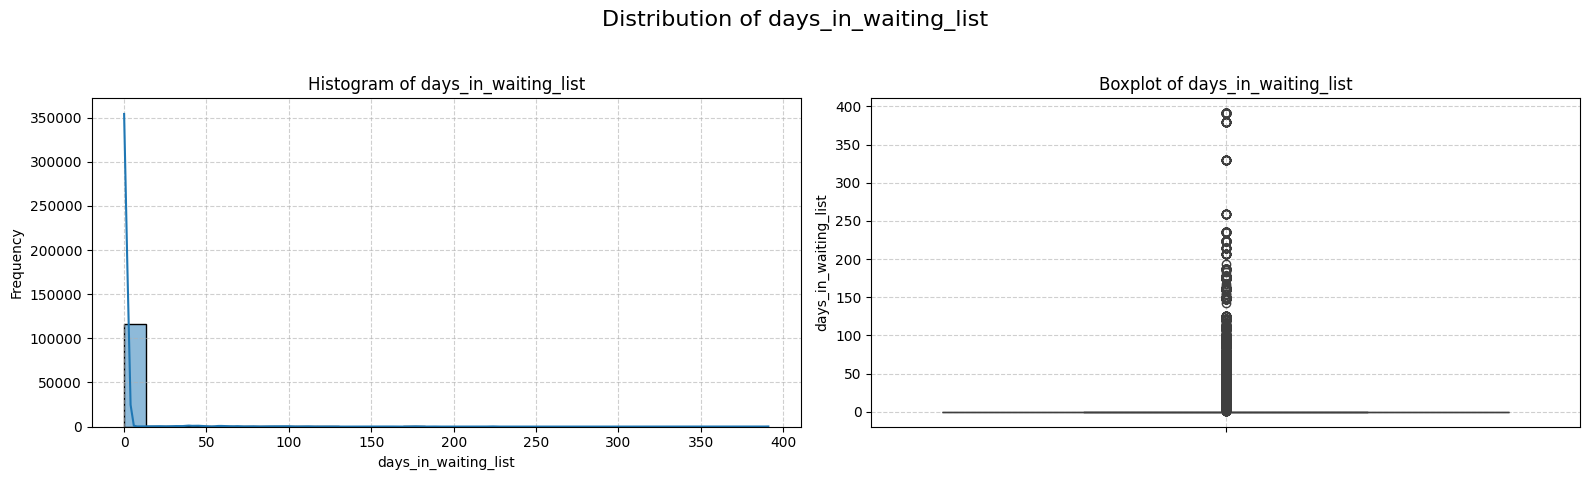

### Variable: adr


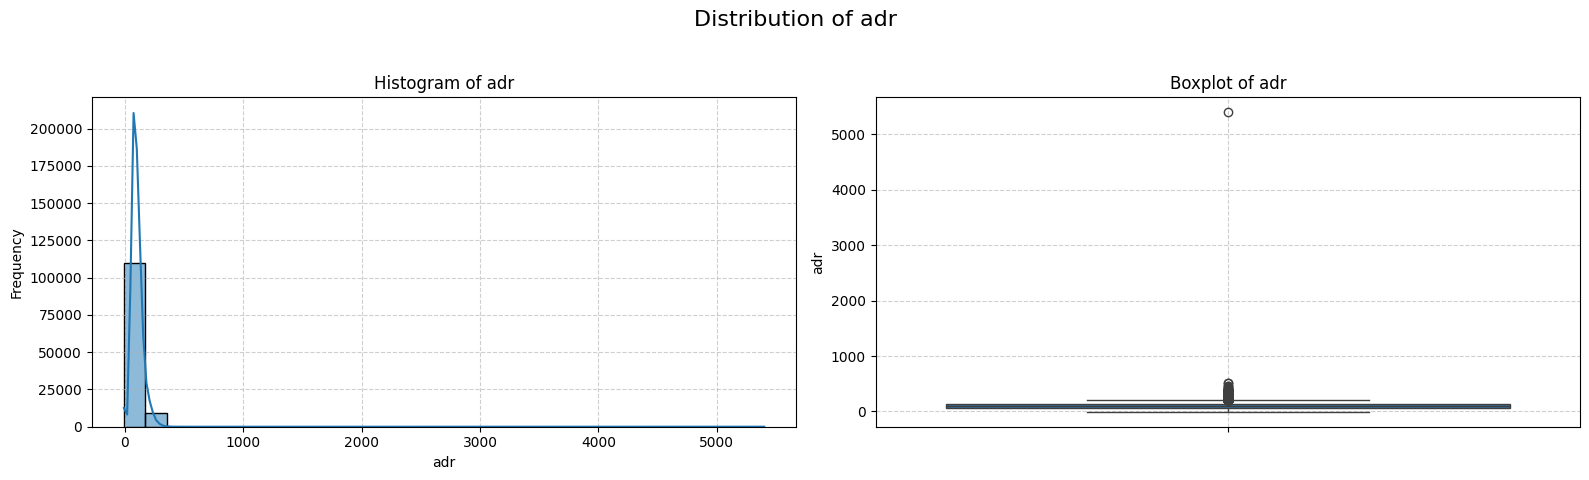

### Variable: required_car_parking_spaces


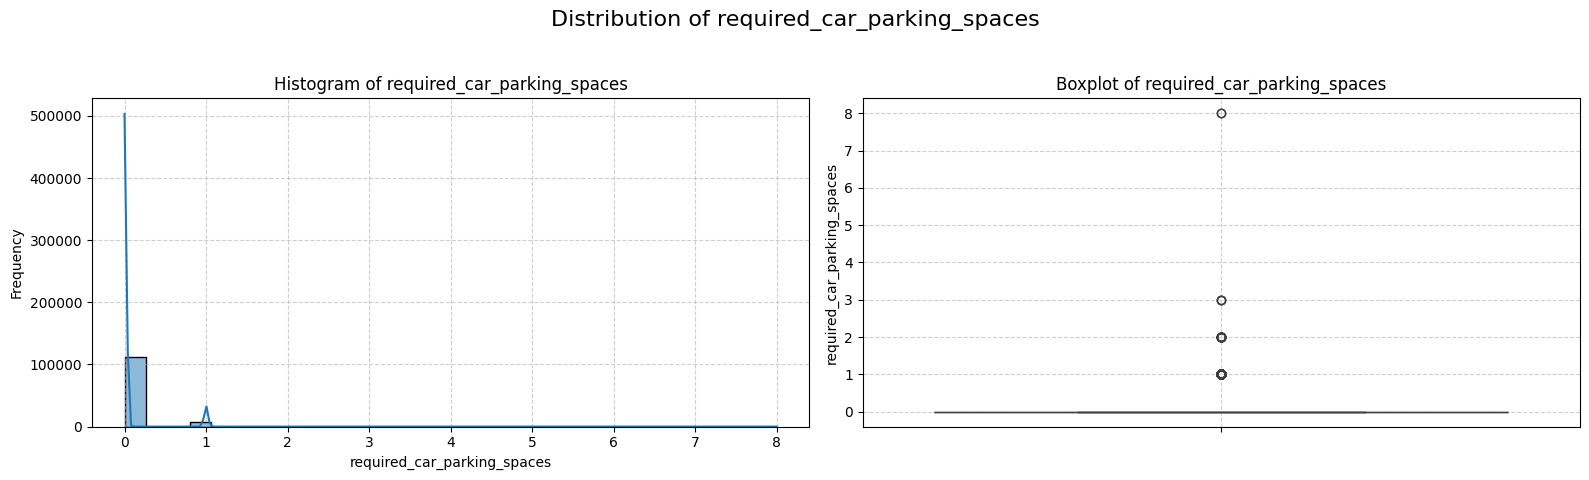

### Variable: total_of_special_requests


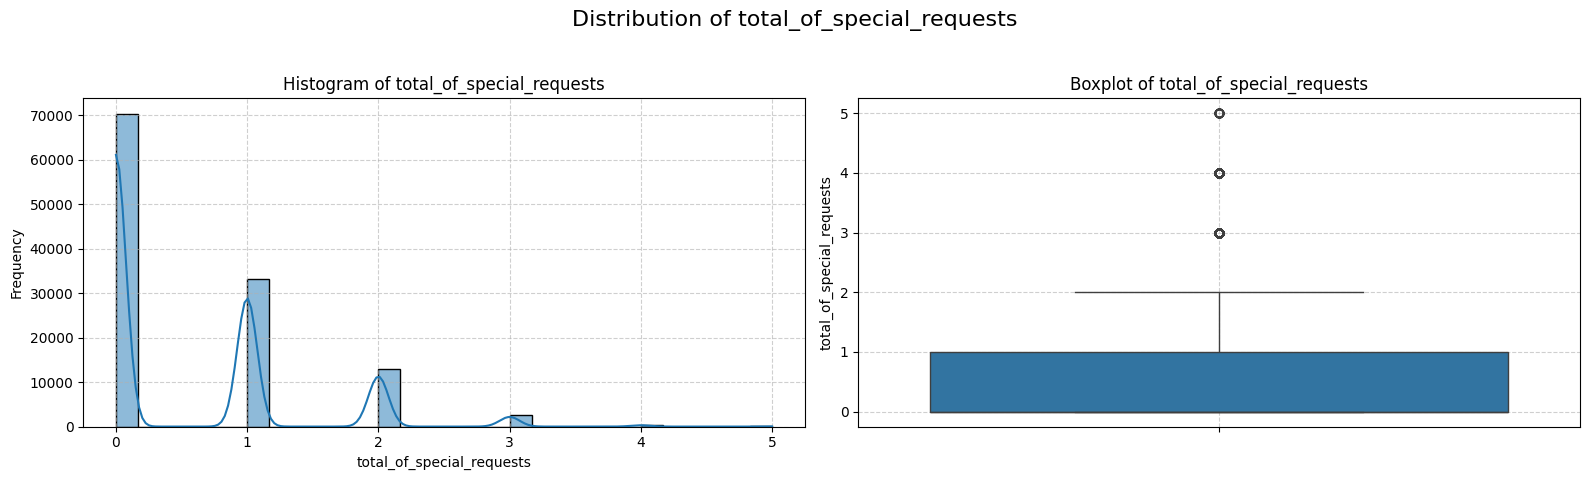

In [9]:
for var in numerical_vars:
    print(f'### Variable: {var}')
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f'Distribution of {var}', fontsize=16)
    sns.histplot(df[var].dropna(), kde=True, ax=axes[0], bins=30)
    axes[0].set_title(f'Histogram of {var}')
    axes[0].set_xlabel(var)
    axes[0].set_ylabel('Frequency')
    axes[0].grid(True, linestyle='--', alpha=0.6)
    sns.boxplot(y=df[var], ax=axes[1])
    axes[1].set_title(f'Boxplot of {var}')
    axes[1].set_ylabel(var)
    axes[1].grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

## 5. Frequency Distribution Analysis for Categorical Variables

### Variable: hotel
Frequency Table:


,Frequency
hotel,
City Hotel,79330
Resort Hotel,40060


Percentage Distribution:


,Percentage
hotel,
City Hotel,66.45
Resort Hotel,33.55


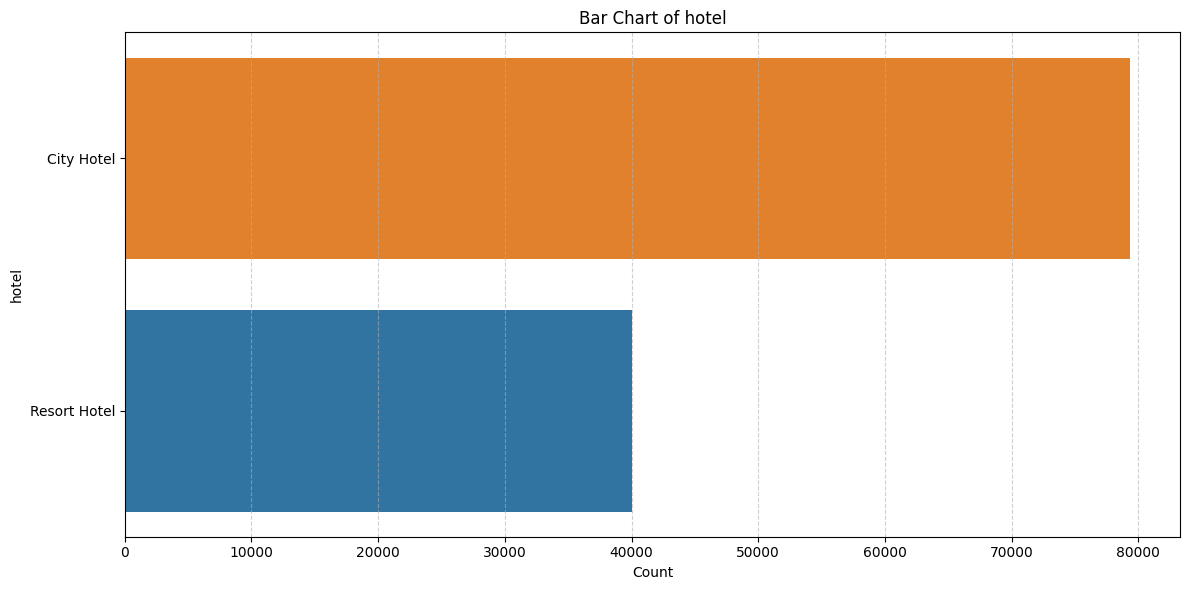

### Variable: arrival_date_month
Frequency Table:


,Frequency
arrival_date_month,
August,13877
July,12661
May,11791
October,11160
April,11089
June,10939
September,10508
March,9794
February,8068


Percentage Distribution:


,Percentage
arrival_date_month,
August,11.62
July,10.60
May,9.88
October,9.35
April,9.29
June,9.16
September,8.80
March,8.20
February,6.76


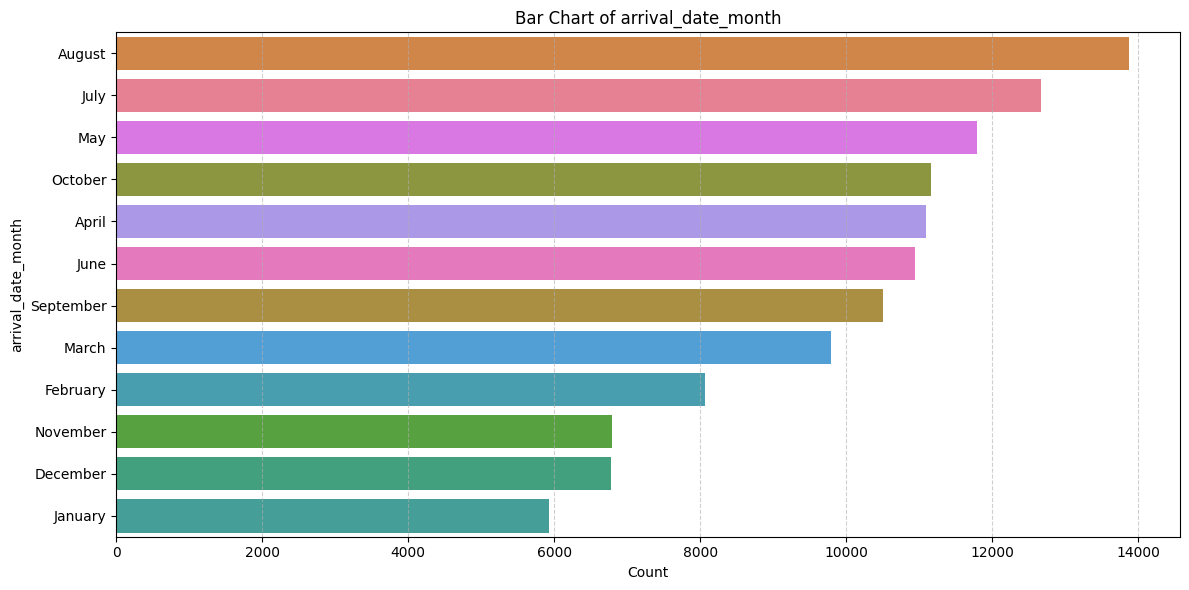

### Variable: meal
Frequency Table:


,Frequency
meal,
BB,92310
HB,14463
SC,10650
Undefined,1169
FB,798


Percentage Distribution:


,Percentage
meal,
BB,77.32
HB,12.11
SC,8.92
Undefined,0.98
FB,0.67


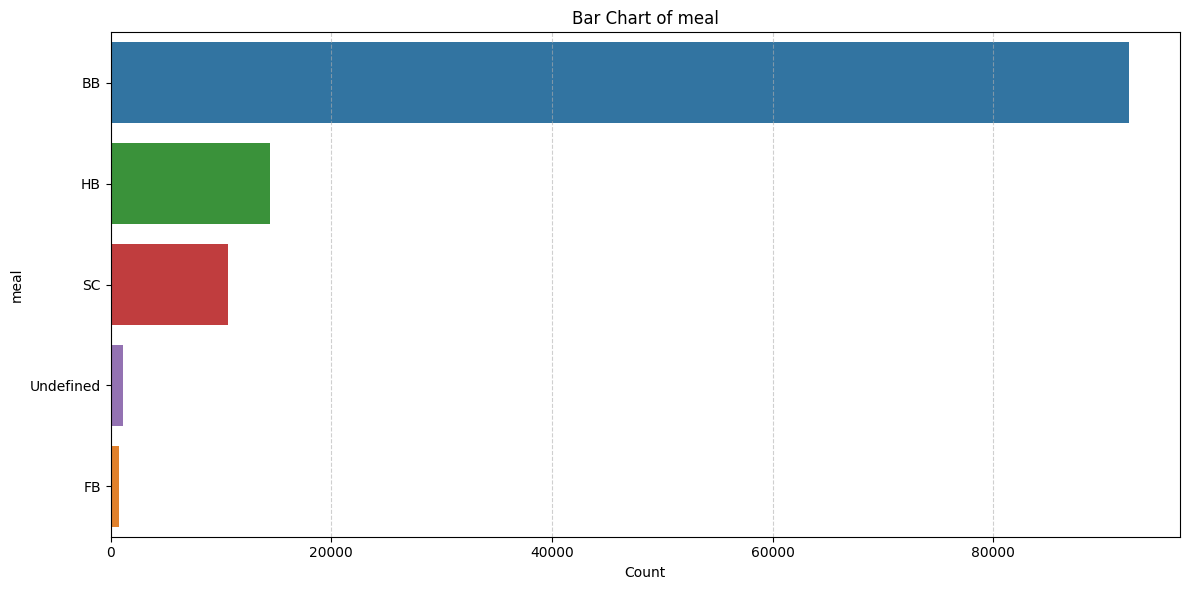

### Variable: country
Frequency Table:


,Frequency
country,
PRT,48590
GBR,12129
FRA,10415
ESP,8568
DEU,7287
...,...
MRT,1
KIR,1
SDN,1


Percentage Distribution:


,Percentage
country,
PRT,40.70
GBR,10.16
FRA,8.72
ESP,7.18
DEU,6.10
...,...
MRT,0.00
KIR,0.00
SDN,0.00


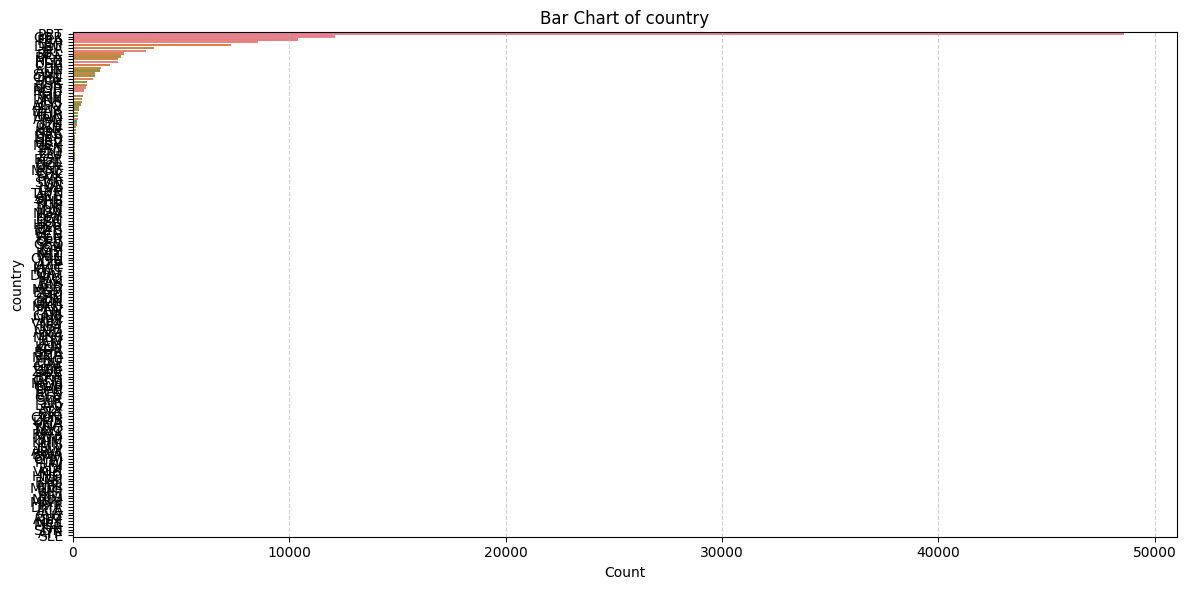

### Variable: market_segment
Frequency Table:


,Frequency
market_segment,
Online TA,56477
Offline TA/TO,24219
Groups,19811
Direct,12606
Corporate,5295
Complementary,743
Aviation,237
Undefined,2


Percentage Distribution:


,Percentage
market_segment,
Online TA,47.30
Offline TA/TO,20.29
Groups,16.59
Direct,10.56
Corporate,4.44
Complementary,0.62
Aviation,0.20
Undefined,0.00


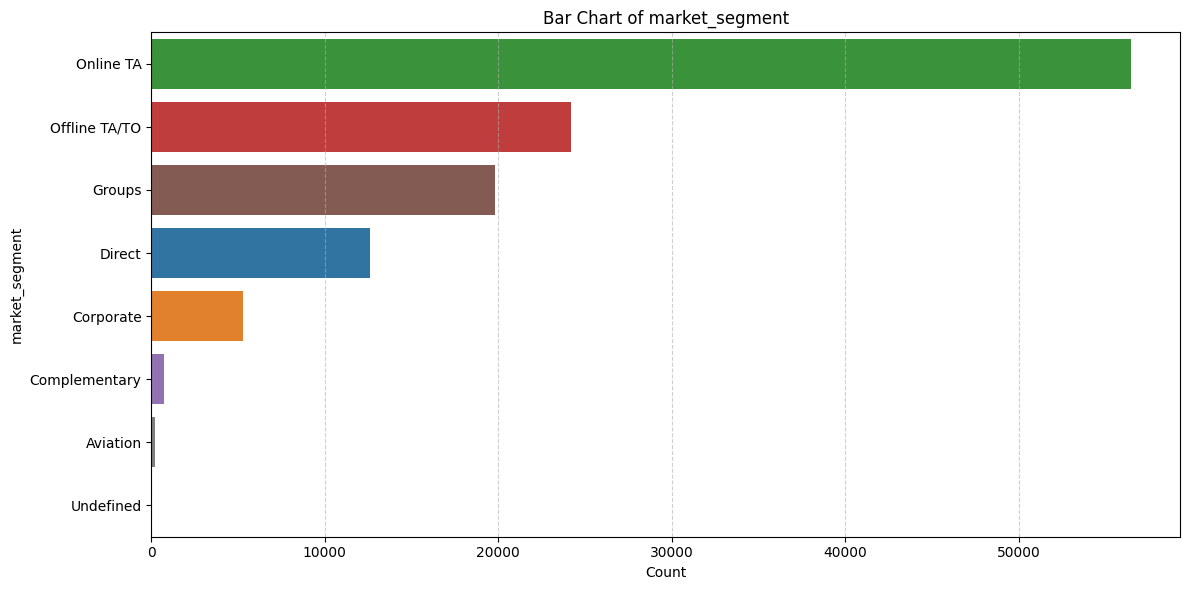

### Variable: distribution_channel
Frequency Table:


,Frequency
distribution_channel,
TA/TO,97870
Direct,14645
Corporate,6677
GDS,193
Undefined,5


Percentage Distribution:


,Percentage
distribution_channel,
TA/TO,81.98
Direct,12.27
Corporate,5.59
GDS,0.16
Undefined,0.00


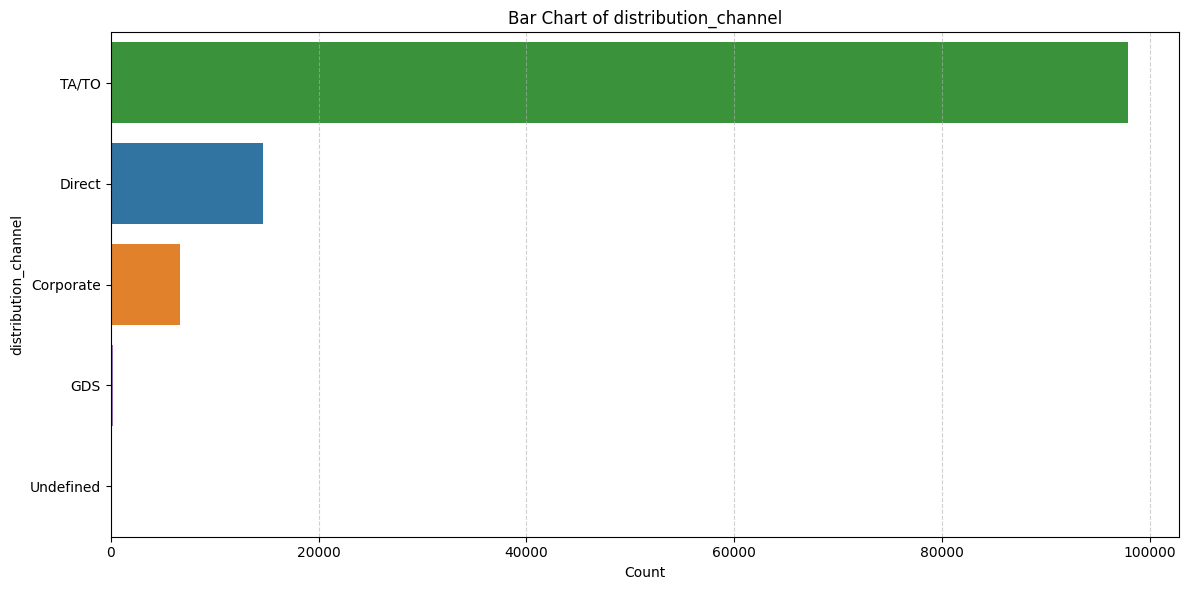

### Variable: reserved_room_type
Frequency Table:


,Frequency
reserved_room_type,
A,85994
D,19201
E,6535
F,2897
G,2094
B,1118
C,932
H,601
P,12


Percentage Distribution:


,Percentage
reserved_room_type,
A,72.03
D,16.08
E,5.47
F,2.43
G,1.75
B,0.94
C,0.78
H,0.50
P,0.01


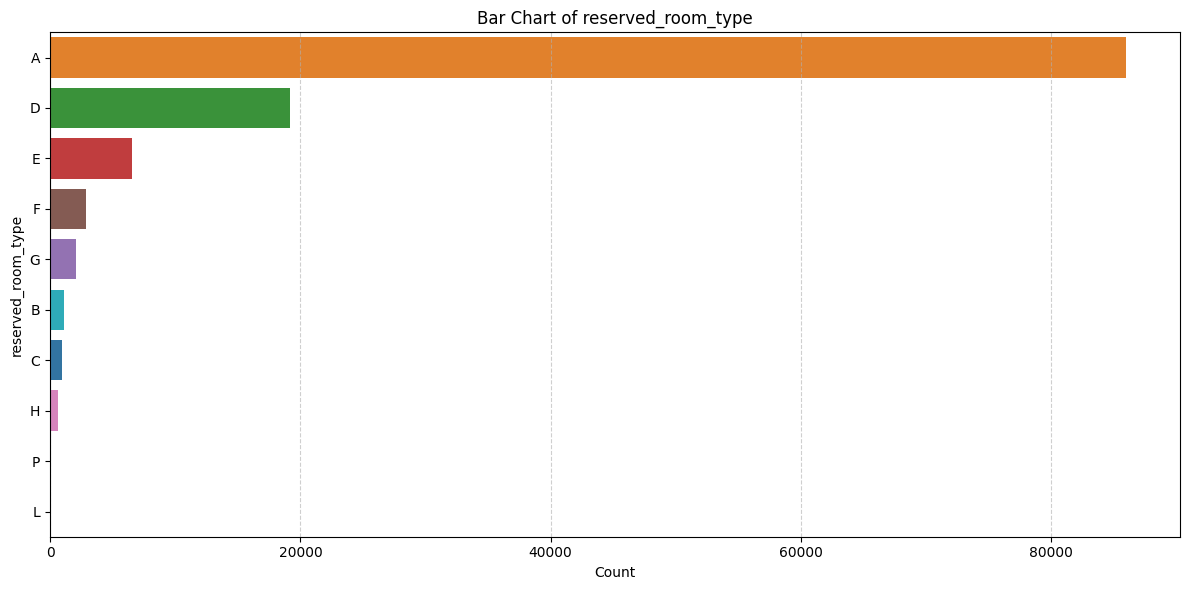

### Variable: assigned_room_type
Frequency Table:


,Frequency
assigned_room_type,
A,74053
D,25322
E,7806
F,3751
G,2553
C,2375
B,2163
H,712
I,363


Percentage Distribution:


,Percentage
assigned_room_type,
A,62.03
D,21.21
E,6.54
F,3.14
G,2.14
C,1.99
B,1.81
H,0.60
I,0.30


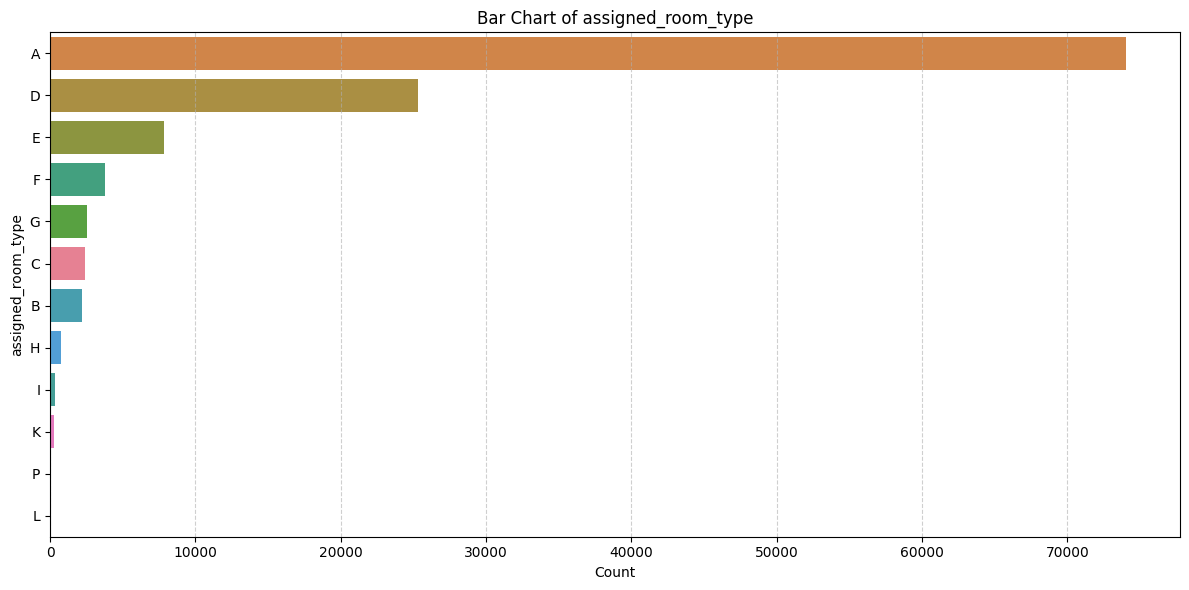

### Variable: deposit_type
Frequency Table:


,Frequency
deposit_type,
No Deposit,104641
Non Refund,14587
Refundable,162


Percentage Distribution:


,Percentage
deposit_type,
No Deposit,87.65
Non Refund,12.22
Refundable,0.14


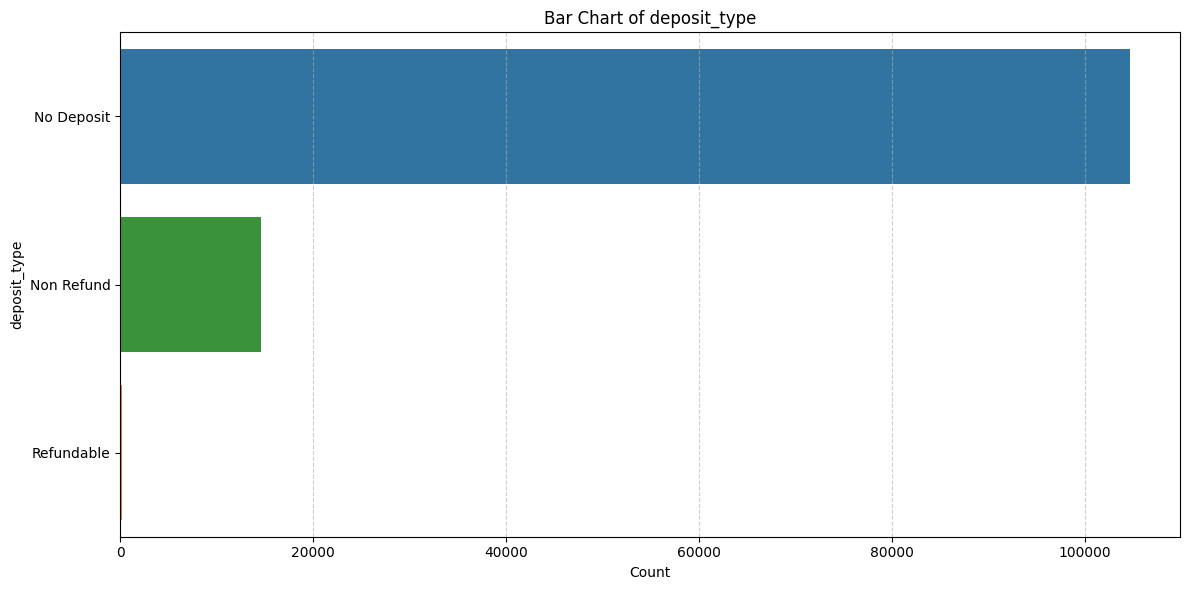

### Variable: customer_type
Frequency Table:


,Frequency
customer_type,
Transient,89613
Transient-Party,25124
Contract,4076
Group,577


Percentage Distribution:


,Percentage
customer_type,
Transient,75.06
Transient-Party,21.04
Contract,3.41
Group,0.48


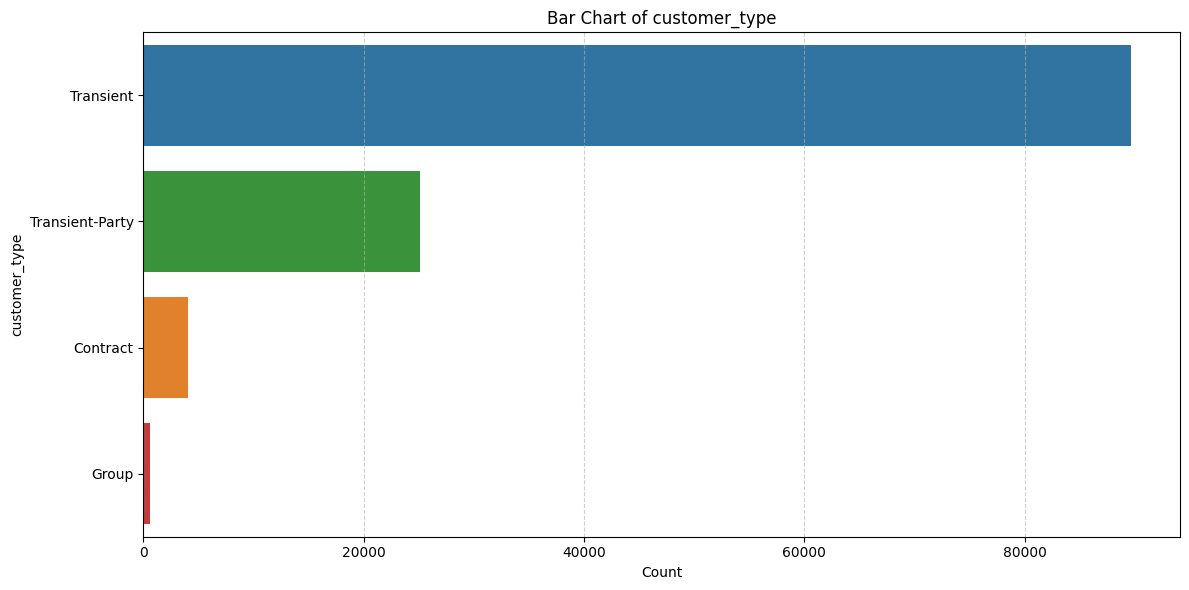

### Variable: reservation_status
Frequency Table:


,Frequency
reservation_status,
Check-Out,75166
Canceled,43017
No-Show,1207


Percentage Distribution:


,Percentage
reservation_status,
Check-Out,62.96
Canceled,36.03
No-Show,1.01


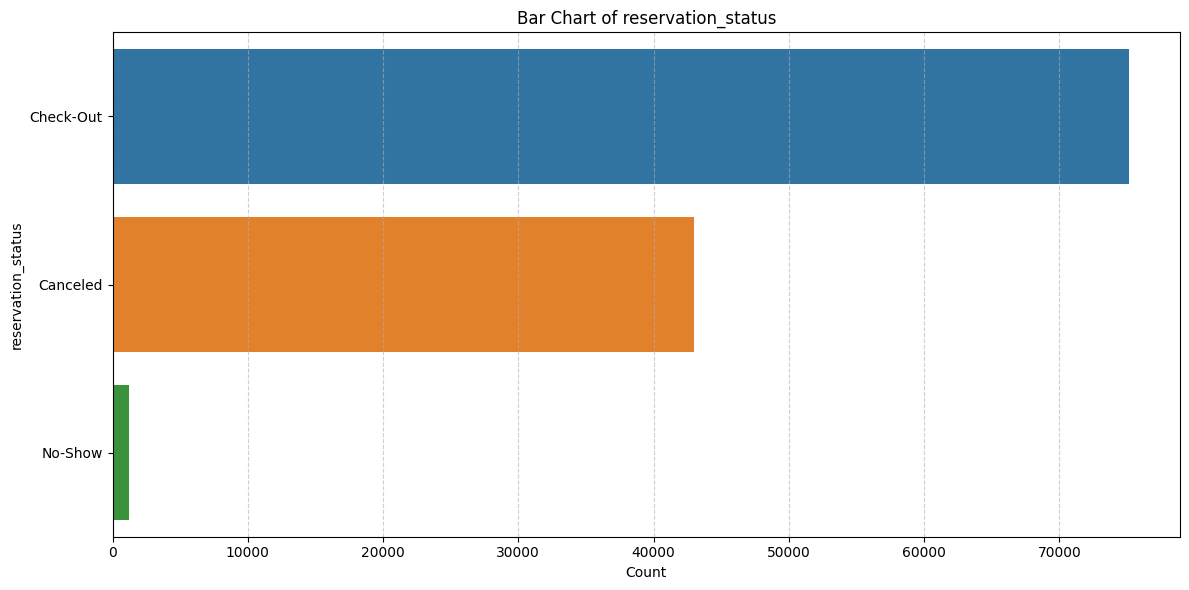

### Variable: reservation_status_date
Frequency Table:


,Frequency
reservation_status_date,
2015-10-21,1461
2015-07-06,805
2016-11-25,790
2015-01-01,763
2016-01-18,625
...,...
2015-02-26,1
2015-03-18,1
2015-03-12,1


Percentage Distribution:


,Percentage
reservation_status_date,
2015-10-21,1.22
2015-07-06,0.67
2016-11-25,0.66
2015-01-01,0.64
2016-01-18,0.52
...,...
2015-02-26,0.00
2015-03-18,0.00
2015-03-12,0.00


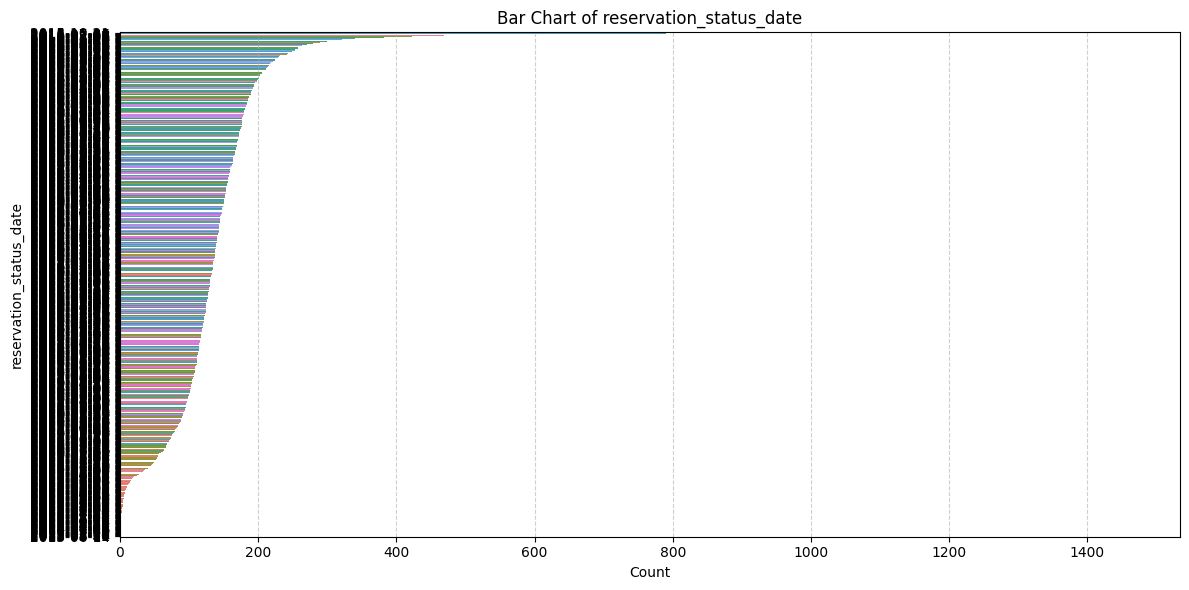

In [10]:
# reservation_status and reservation_status_date are shown separately only as data-quality/context fields
# because they are post-outcome variables and should not be used as predictors of is_canceled.
for var in categorical_vars:
    print(f'### Variable: {var}')
    freq_table = df[var].value_counts(dropna=False)
    print('Frequency Table:')
    display(freq_table.to_frame('Frequency'))
    print('Percentage Distribution:')
    display((df[var].value_counts(dropna=False, normalize=True) * 100).round(2).to_frame('Percentage'))
    plt.figure(figsize=(12, 6))
    order = df[var].value_counts(dropna=False).index
    sns.countplot(data=df, y=var, order=order, hue=var, legend=False)
    plt.title(f'Bar Chart of {var}')
    plt.xlabel('Count')
    plt.ylabel(var)
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

## 6. Detailed Missing Value Analysis

In [11]:
missing_data = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum() / len(df)) * 100
})
missing_data = missing_data[missing_data['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)
print('Missing Value Summary:')
if missing_data.empty:
    print('No missing values found in the dataset.')
else:
    display(missing_data)

Missing Value Summary:


,Missing Count,Missing Percentage
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350


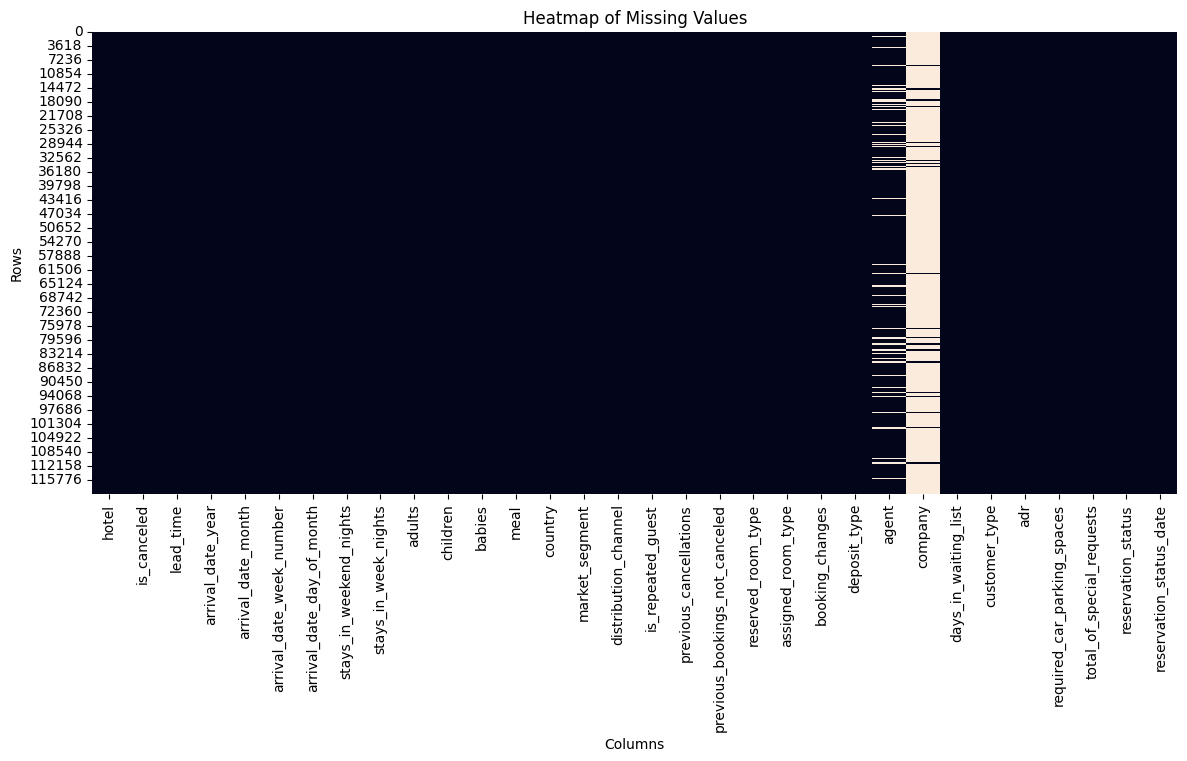

In [12]:
plt.figure(figsize=(14, 6))
sns.heatmap(df.isnull(), cbar=False)
plt.title('Heatmap of Missing Values')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

## 7. Outlier Detection Using IQR

In [13]:
for var in numerical_vars:
    if var == target_variable:
        continue
    print(f'### Variable: {var}')
    series = df[var].dropna()
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[var] < lower_bound) | (df[var] > upper_bound)]
    outlier_count = outliers.shape[0]
    outlier_percentage = (outlier_count / len(df)) * 100
    print(f'IQR: {IQR:.2f}')
    print(f'Lower Bound: {lower_bound:.2f}')
    print(f'Upper Bound: {upper_bound:.2f}')
    print(f'Number of Outliers: {outlier_count}')
    print(f'Percentage of Outliers: {outlier_percentage:.2f}%\n')

### Variable: lead_time
IQR: 142.00
Lower Bound: -195.00
Upper Bound: 373.00
Number of Outliers: 3005
Percentage of Outliers: 2.52%

### Variable: arrival_date_year
IQR: 1.00
Lower Bound: 2014.50
Upper Bound: 2018.50
Number of Outliers: 0
Percentage of Outliers: 0.00%

### Variable: arrival_date_week_number
IQR: 22.00
Lower Bound: -17.00
Upper Bound: 71.00
Number of Outliers: 0
Percentage of Outliers: 0.00%

### Variable: arrival_date_day_of_month
IQR: 15.00
Lower Bound: -14.50
Upper Bound: 45.50
Number of Outliers: 0
Percentage of Outliers: 0.00%

### Variable: stays_in_weekend_nights
IQR: 2.00
Lower Bound: -3.00
Upper Bound: 5.00
Number of Outliers: 265
Percentage of Outliers: 0.22%

### Variable: stays_in_week_nights
IQR: 2.00
Lower Bound: -2.00
Upper Bound: 6.00
Number of Outliers: 3354
Percentage of Outliers: 2.81%

### Variable: adults
IQR: 0.00
Lower Bound: 2.00
Upper Bound: 2.00
Number of Outliers: 29710
Percentage of Outliers: 24.88%

### Variable: children
IQR: 0.00
Lower Bou

## 8. Correlation Analysis

Correlation Matrix:


,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
lead_time,1.000000,0.040142,0.126871,0.002268,0.085671,0.165799,0.119519,-0.037622,-0.020915,-0.124410,0.086042,-0.073548,0.000149,-0.069741,0.151464,0.170084,-0.063077,-0.116451,-0.095712
arrival_date_year,0.040142,1.000000,-0.540561,-0.000221,0.021497,0.030883,0.029635,0.054624,-0.013192,0.010341,-0.119822,0.029218,0.030872,0.063457,0.259095,-0.056497,0.197580,-0.013684,0.108531
arrival_date_week_number,0.126871,-0.540561,1.000000,0.066809,0.018208,0.015558,0.025909,0.005518,0.010395,-0.030131,0.035501,-0.020904,0.005508,-0.031201,-0.076760,0.022933,0.075791,0.001920,0.026149
arrival_date_day_of_month,0.002268,-0.000221,0.066809,1.000000,-0.016354,-0.028174,-0.001566,0.014544,-0.000230,-0.006145,-0.027011,-0.000300,0.010613,0.001487,0.044858,0.022728,0.030245,0.008683,0.003062
stays_in_weekend_nights,0.085671,0.021497,0.018208,-0.016354,1.000000,0.498969,0.091871,0.045793,0.018483,-0.087239,-0.012775,-0.042715,0.063281,0.140739,0.066749,-0.054151,0.049342,-0.018554,0.072671
stays_in_week_nights,0.165799,0.030883,0.015558,-0.028174,0.498969,1.000000,0.092976,0.044203,0.020191,-0.097245,-0.013992,-0.048743,0.096209,0.182382,0.182211,-0.002020,0.065237,-0.024859,0.068192
adults,0.119519,0.029635,0.025909,-0.001566,0.091871,0.092976,1.000000,0.030447,0.018146,-0.146426,-0.006738,-0.107983,-0.051673,-0.035594,0.207793,-0.008283,0.230641,0.014785,0.122884
children,-0.037622,0.054624,0.005518,0.014544,0.045793,0.044203,0.030447,1.000000,0.024030,-0.032859,-0.024730,-0.021072,0.048949,0.041066,0.030931,-0.033273,0.324854,0.056253,0.081745
babies,-0.020915,-0.013192,0.010395,-0.000230,0.018483,0.020191,0.018146,0.024030,1.000000,-0.008943,-0.007501,-0.006550,0.083440,0.036184,0.019206,-0.010621,0.029186,0.037383,0.097889
is_repeated_guest,-0.124410,0.010341,-0.030131,-0.006145,-0.087239,-0.097245,-0.146426,-0.032859,-0.008943,1.000000,0.082293,0.418056,0.012092,0.031527,-0.244586,-0.022235,-0.134314,0.077090,0.013050


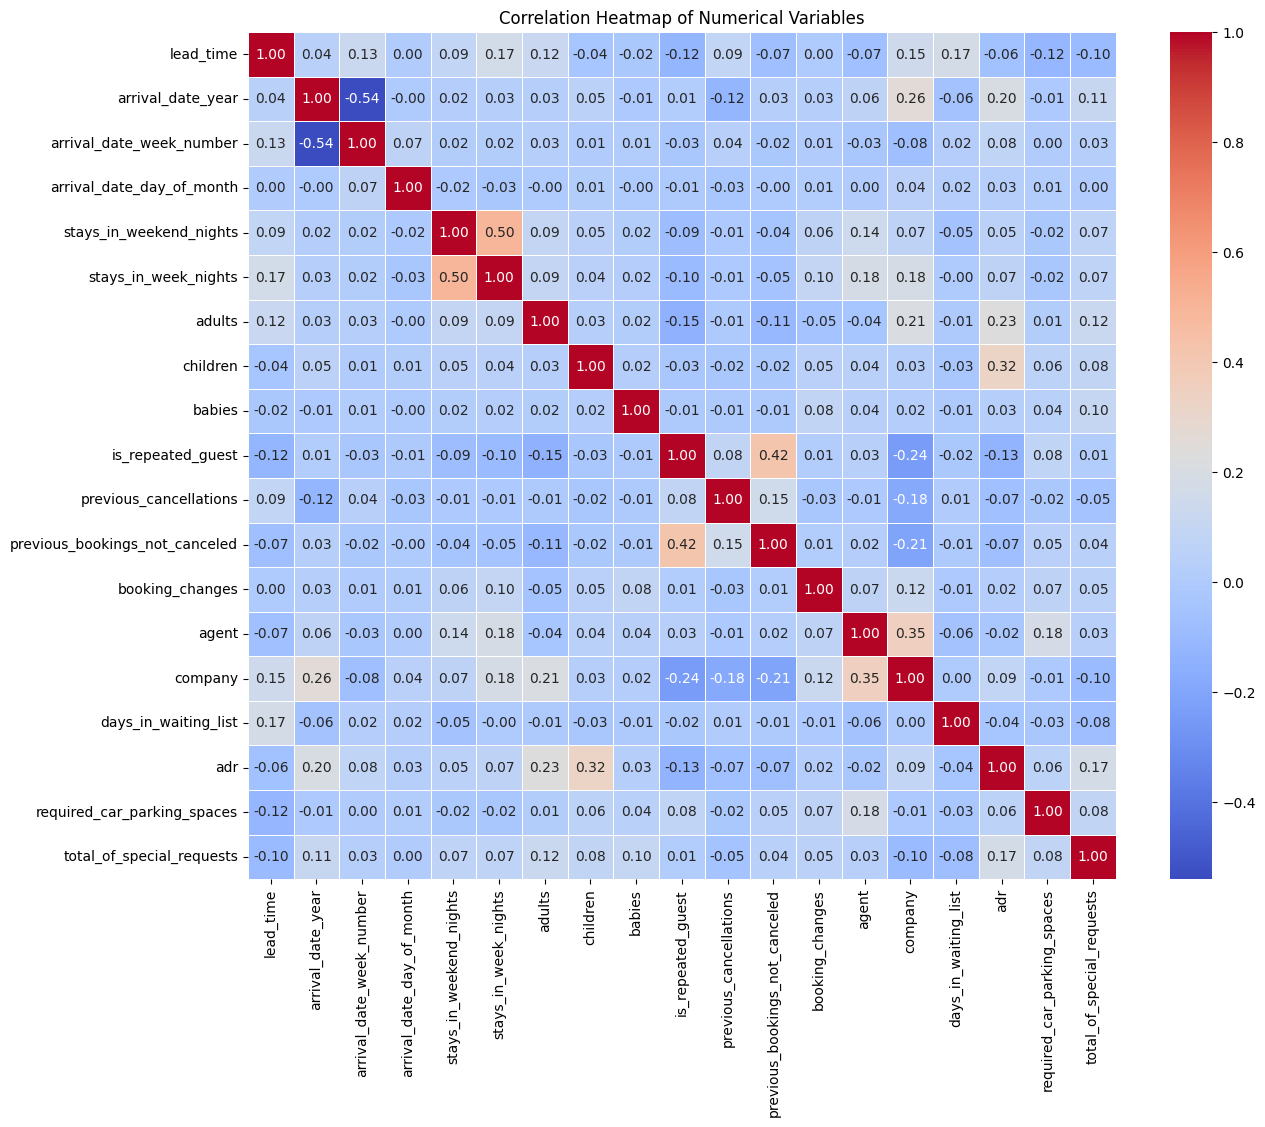

In [14]:
corr_vars = [v for v in numerical_vars if v != target_variable]
correlation_matrix = df[corr_vars].corr()
print('Correlation Matrix:')
display(correlation_matrix)

plt.figure(figsize=(14, 11))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

## 9. Relationship Analysis with `is_canceled`

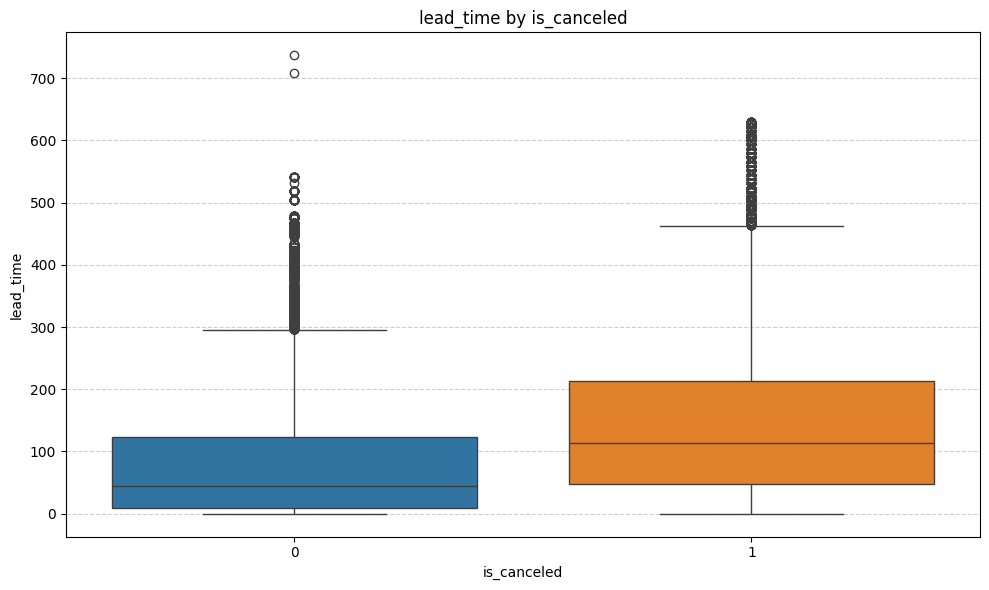

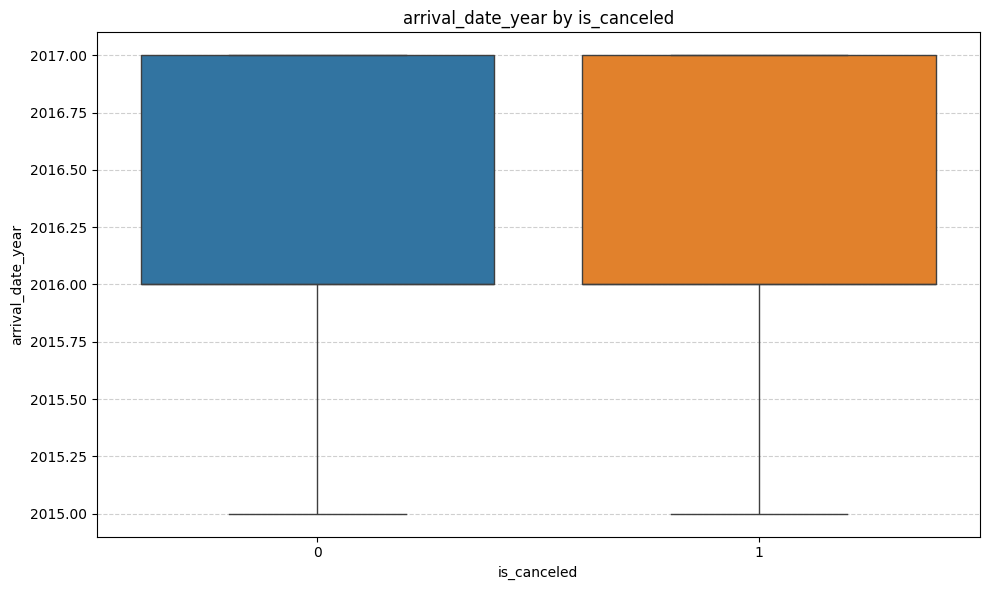

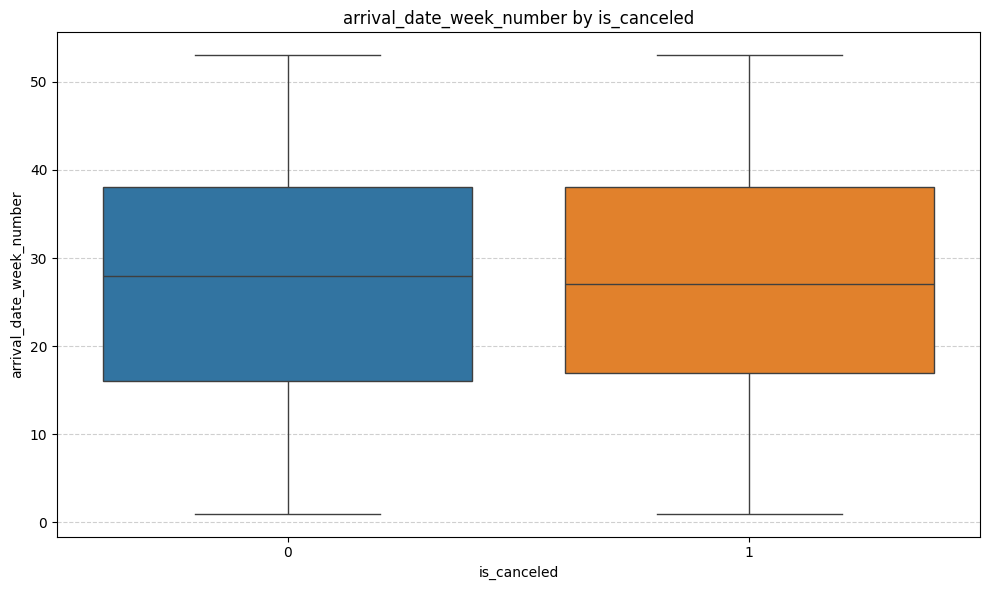

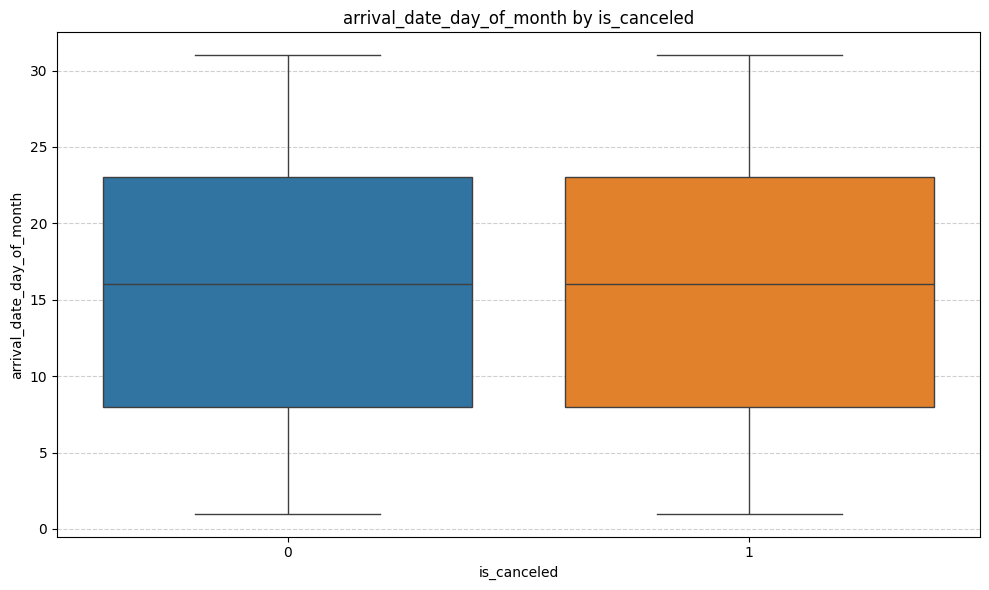

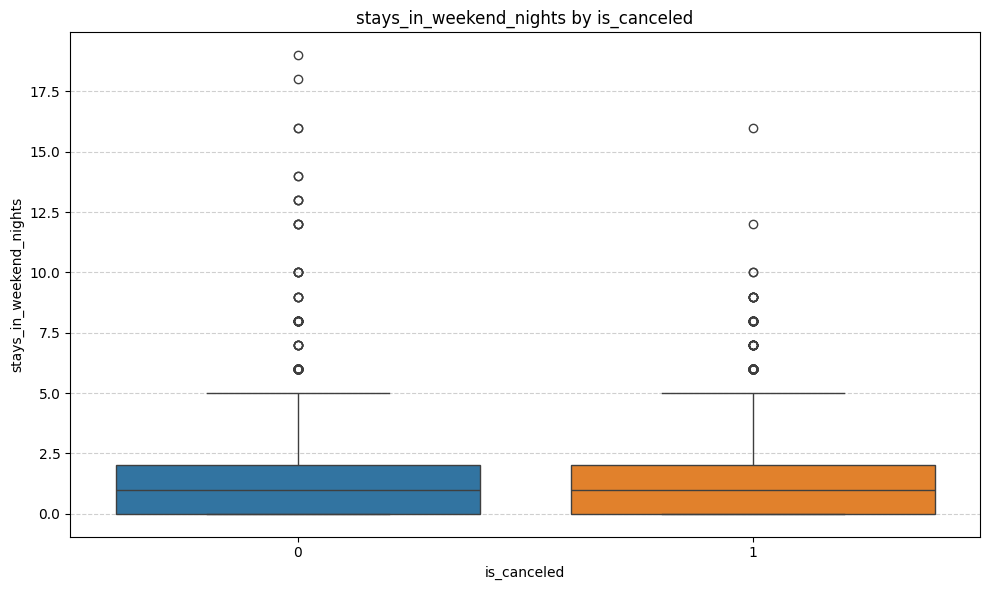

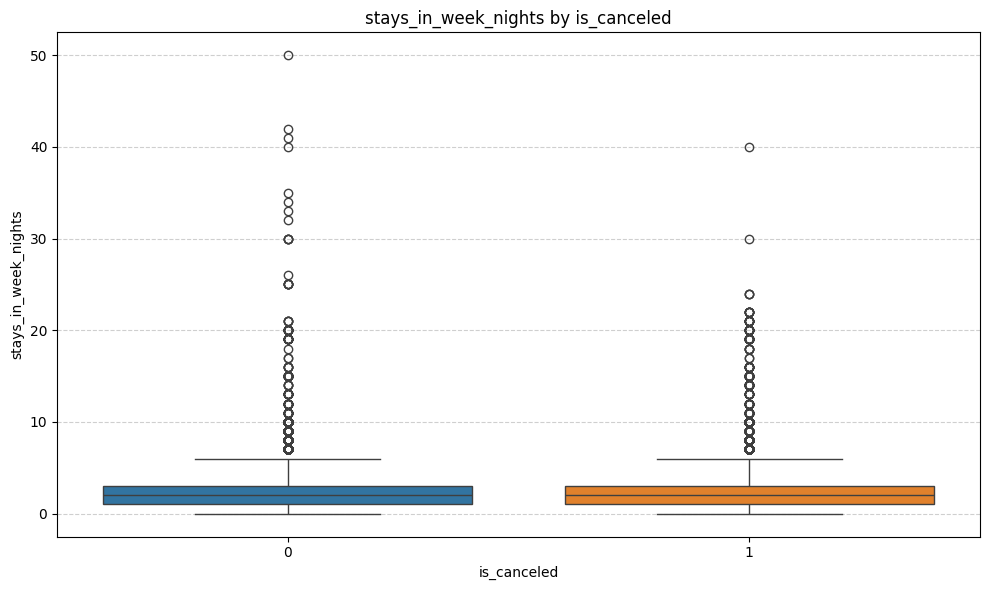

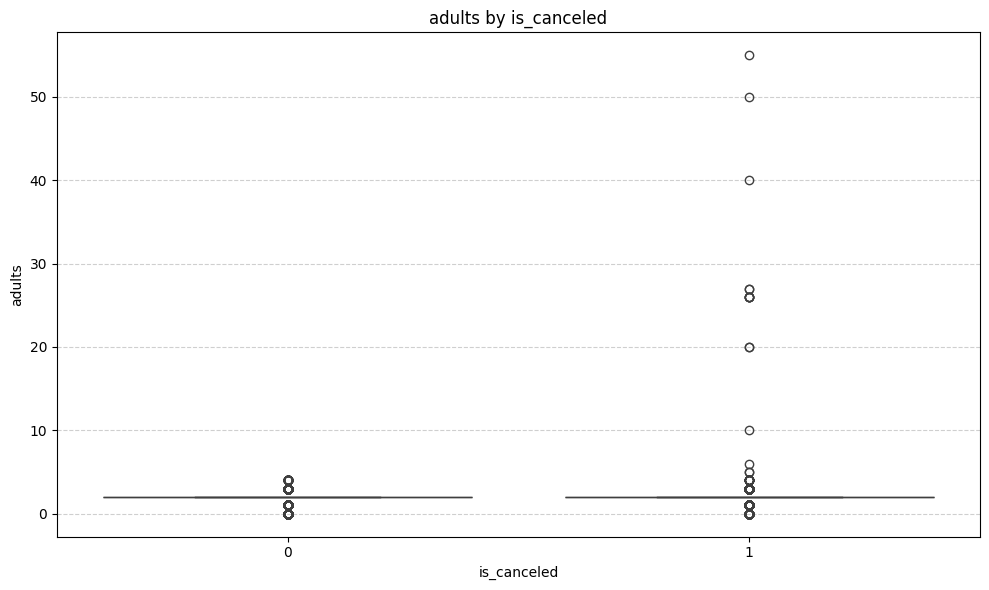

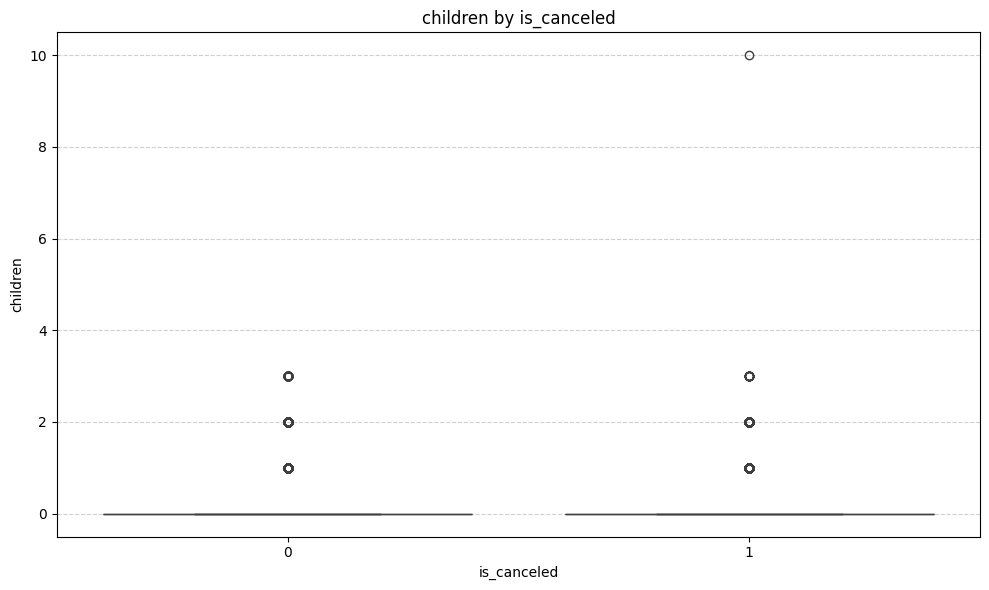

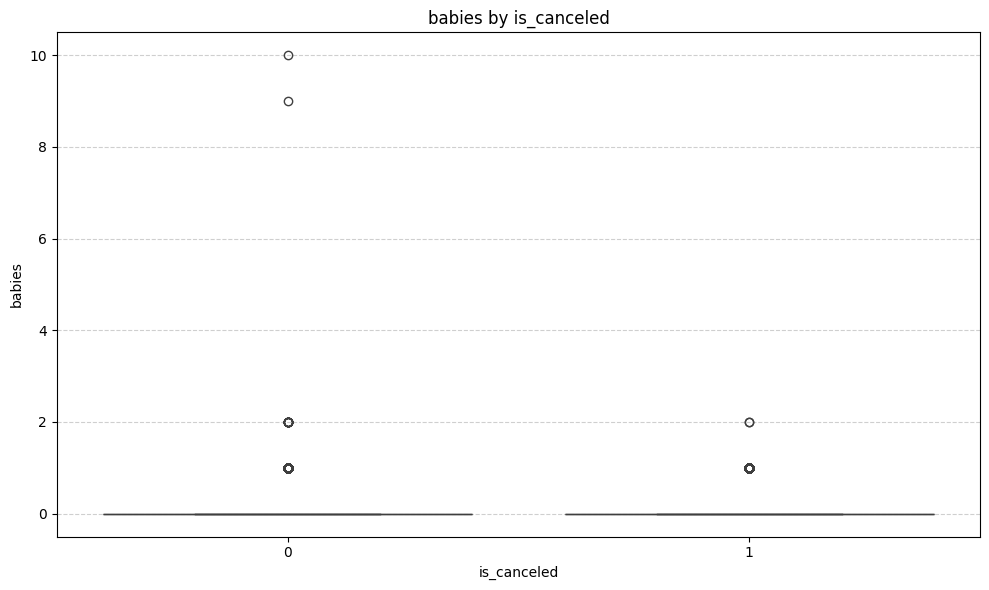

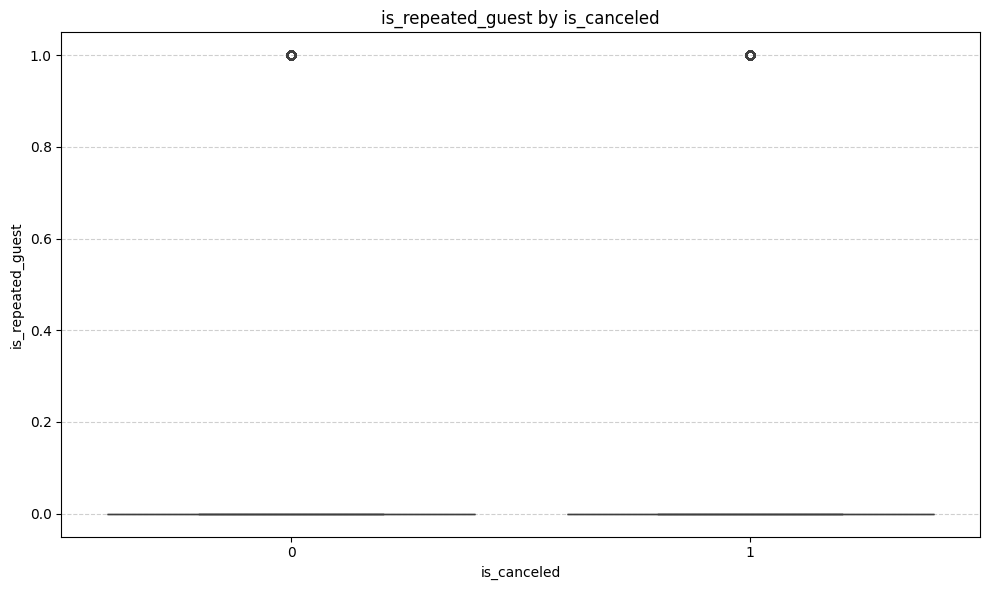

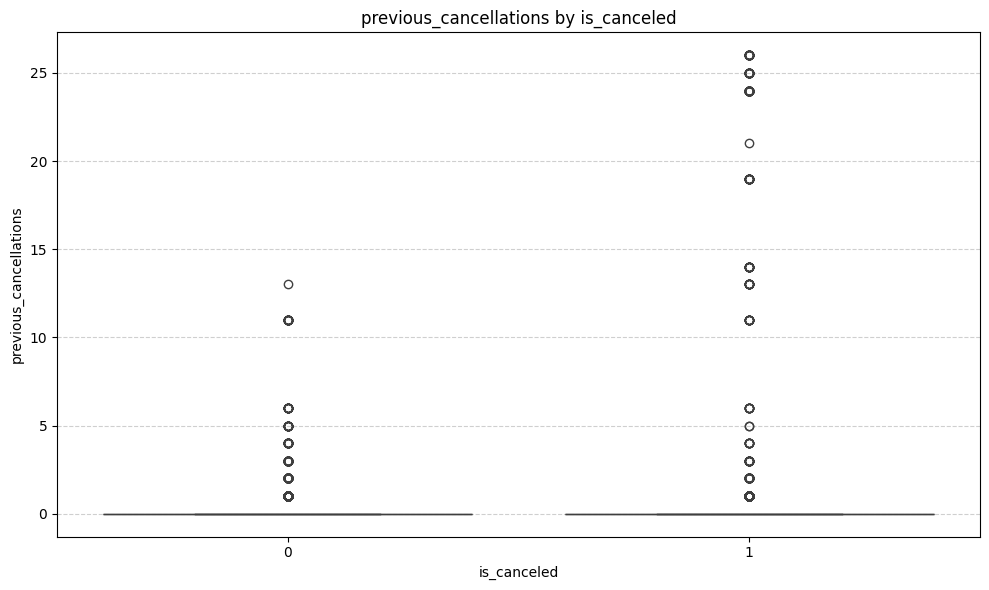

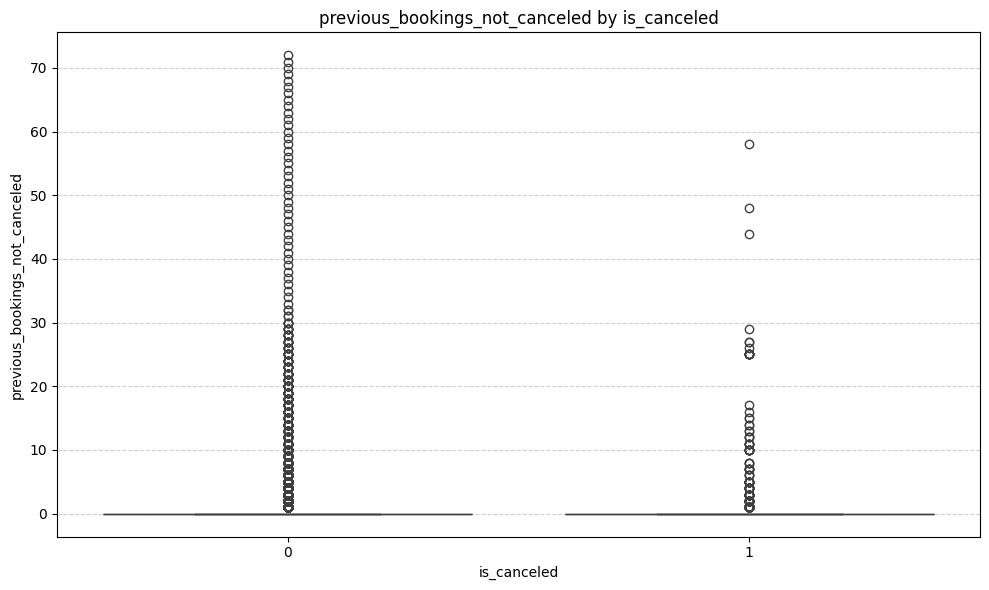

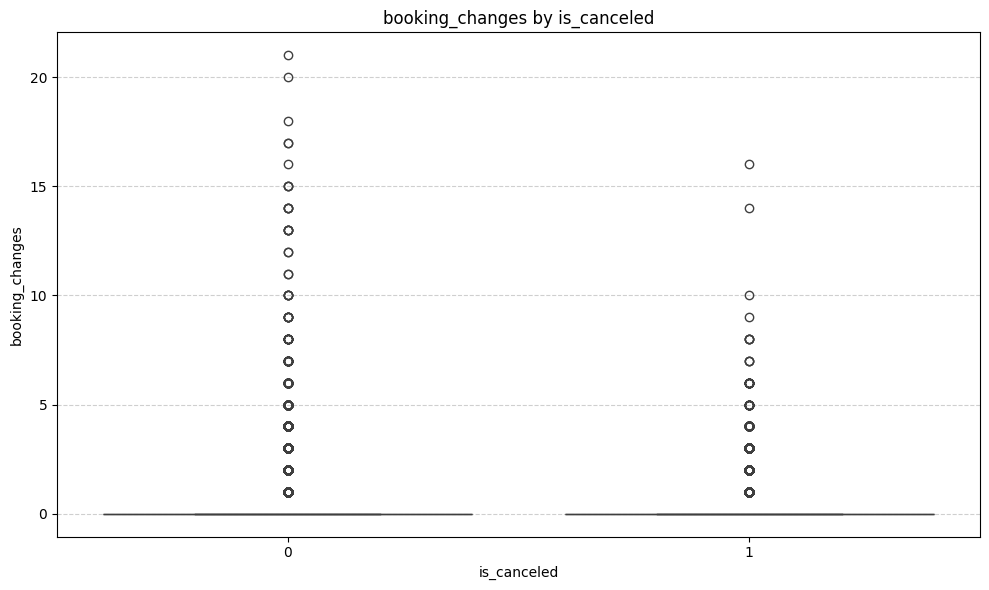

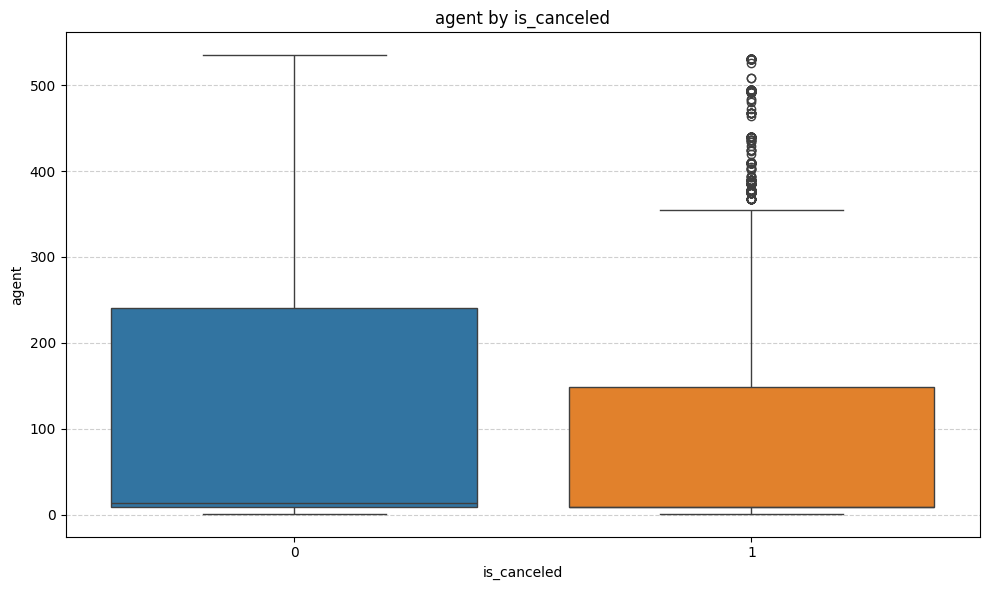

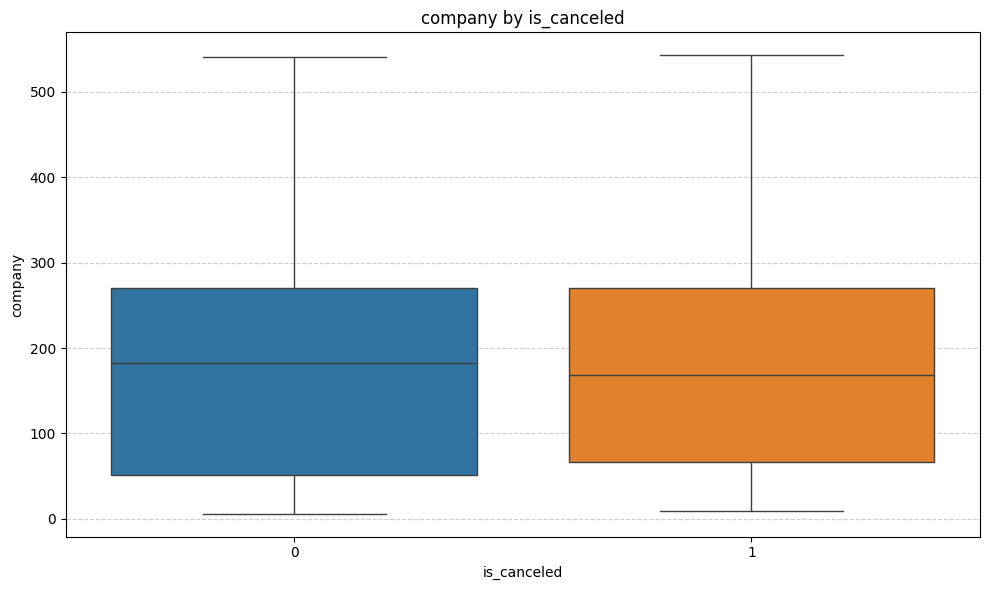

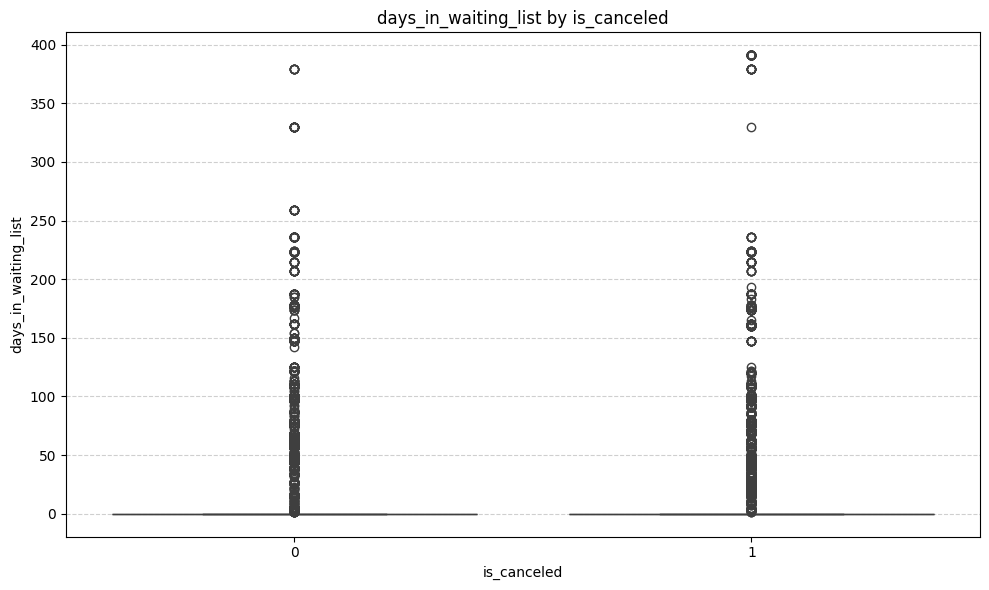

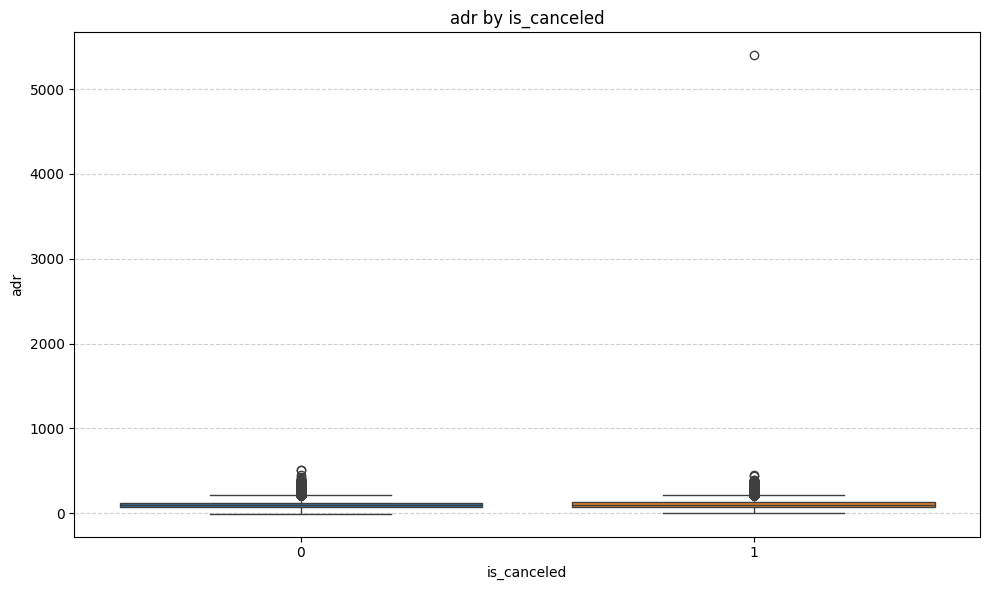

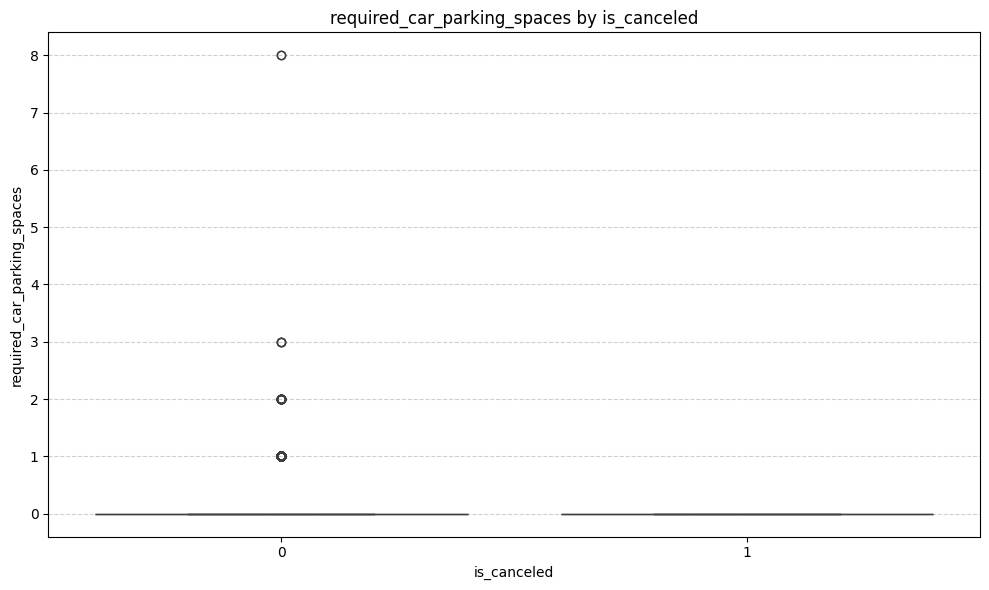

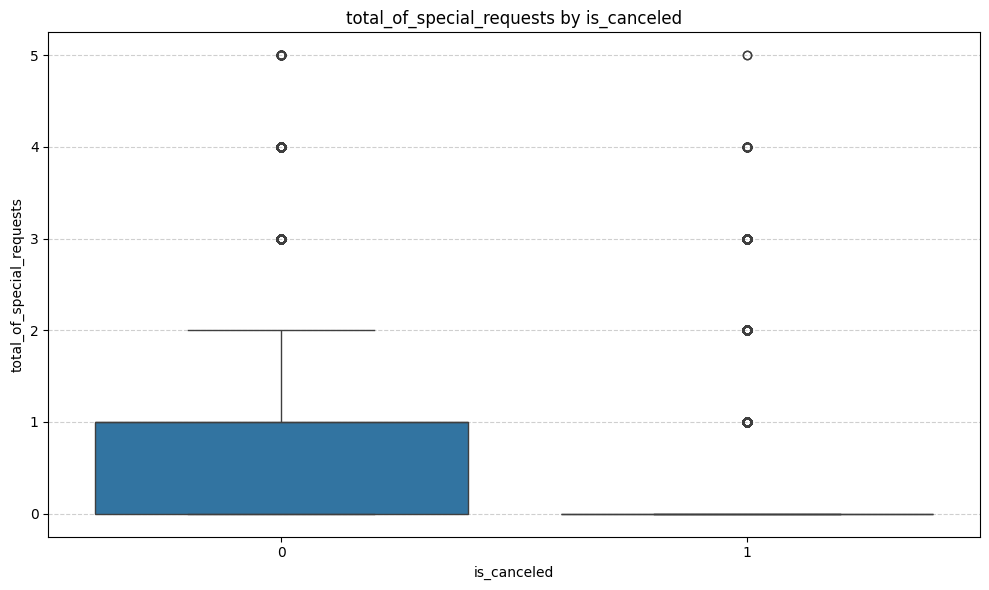

In [15]:
for var in corr_vars:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=target_variable, y=var, data=df, hue=target_variable, legend=False)
    plt.title(f'{var} by is_canceled')
    plt.xlabel('is_canceled')
    plt.ylabel(var)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

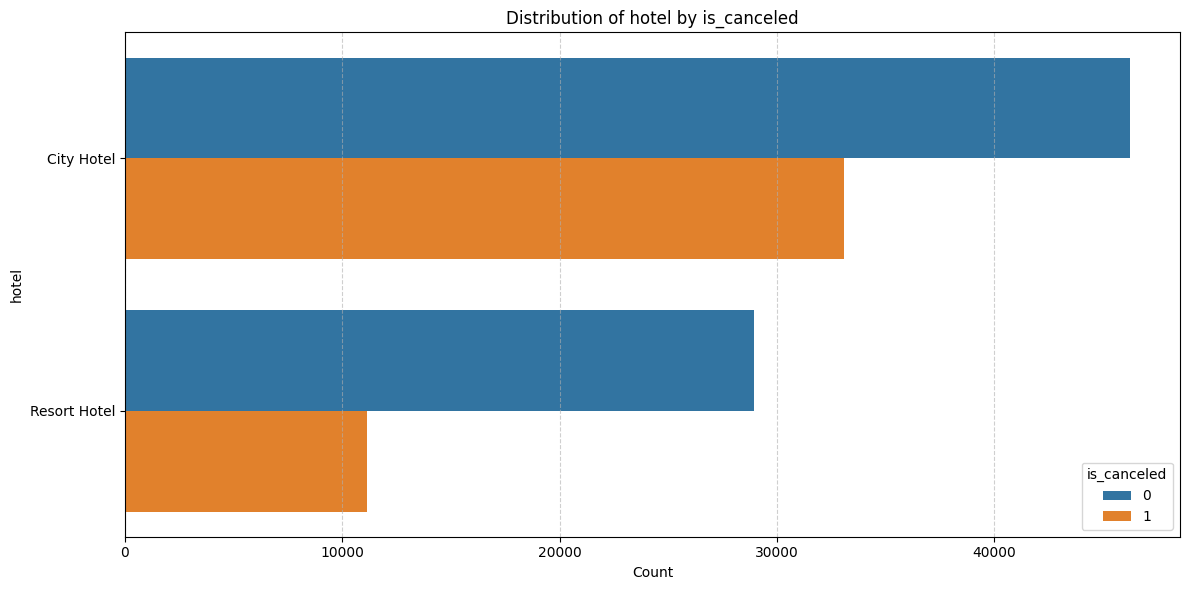

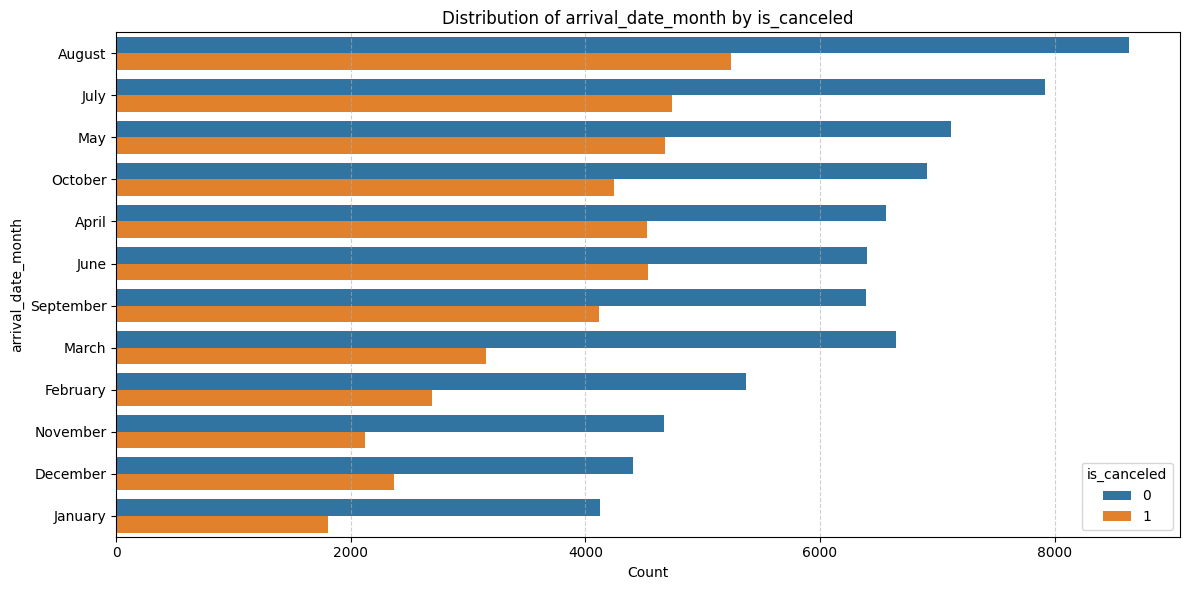

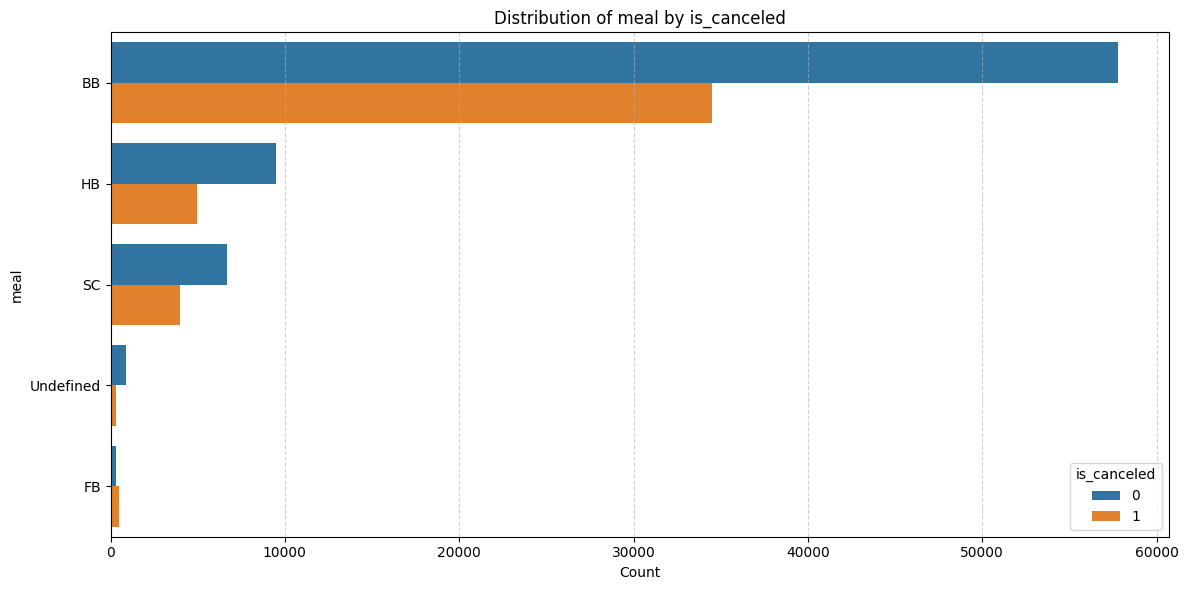

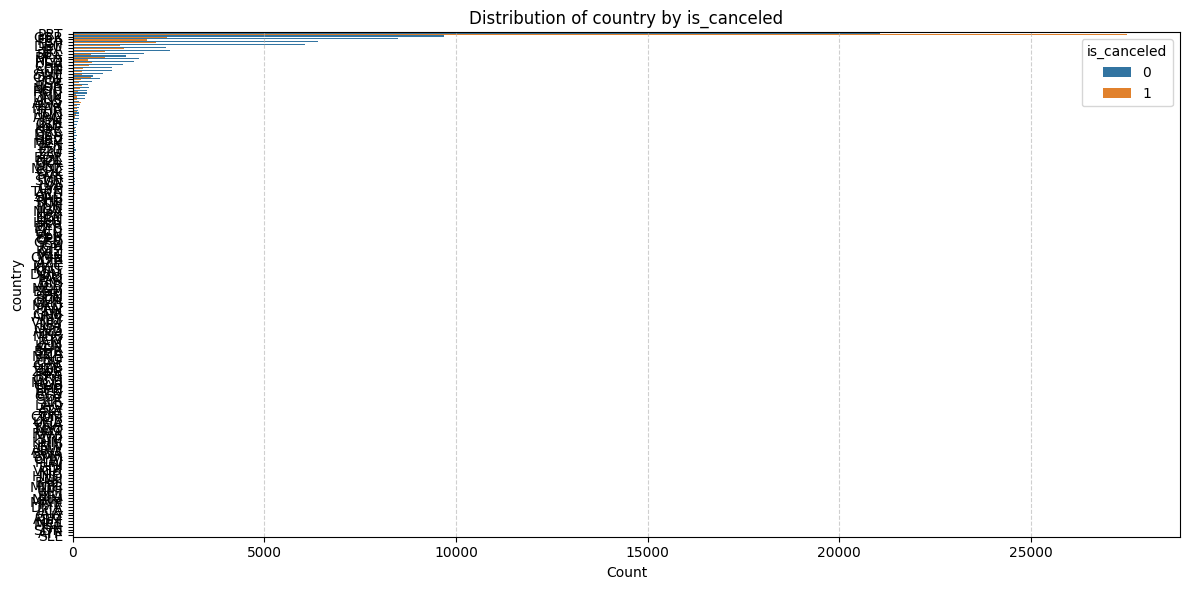

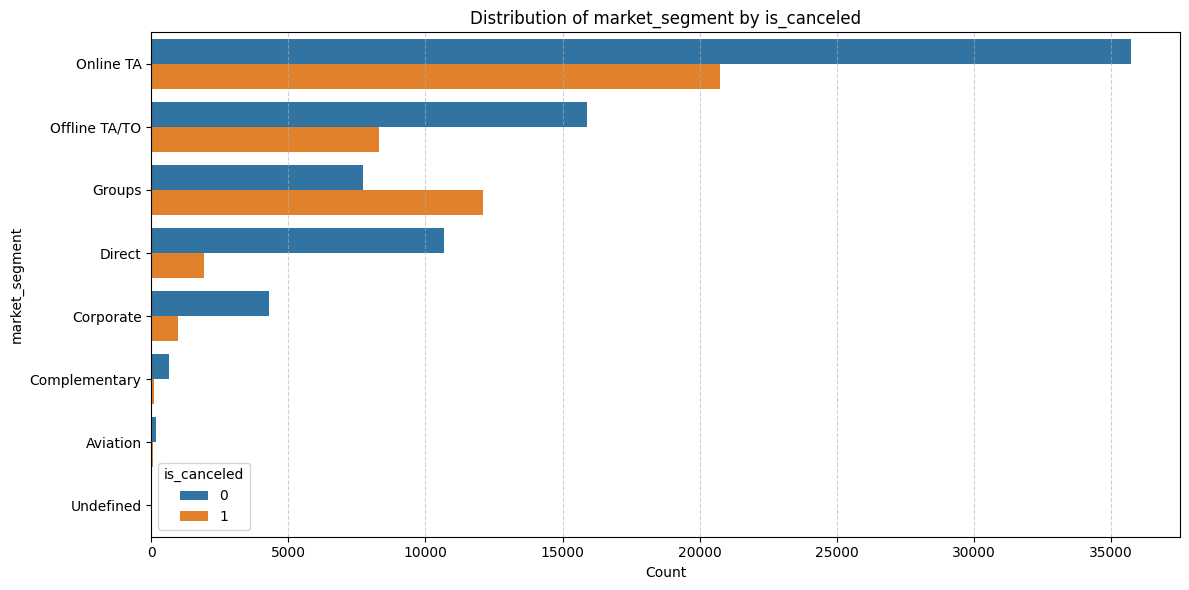

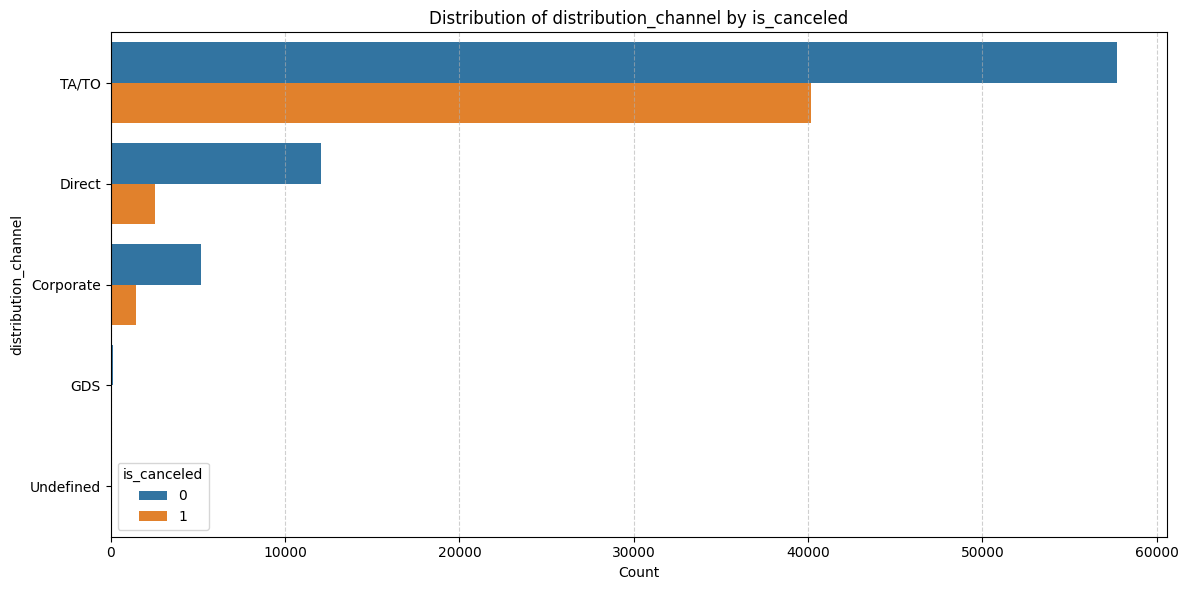

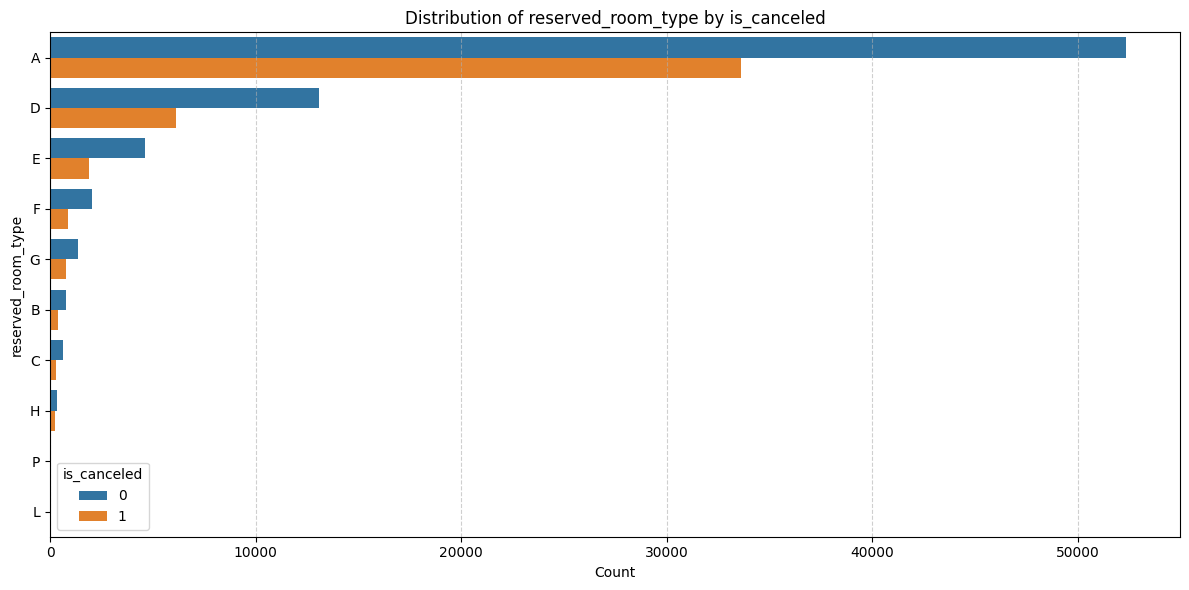

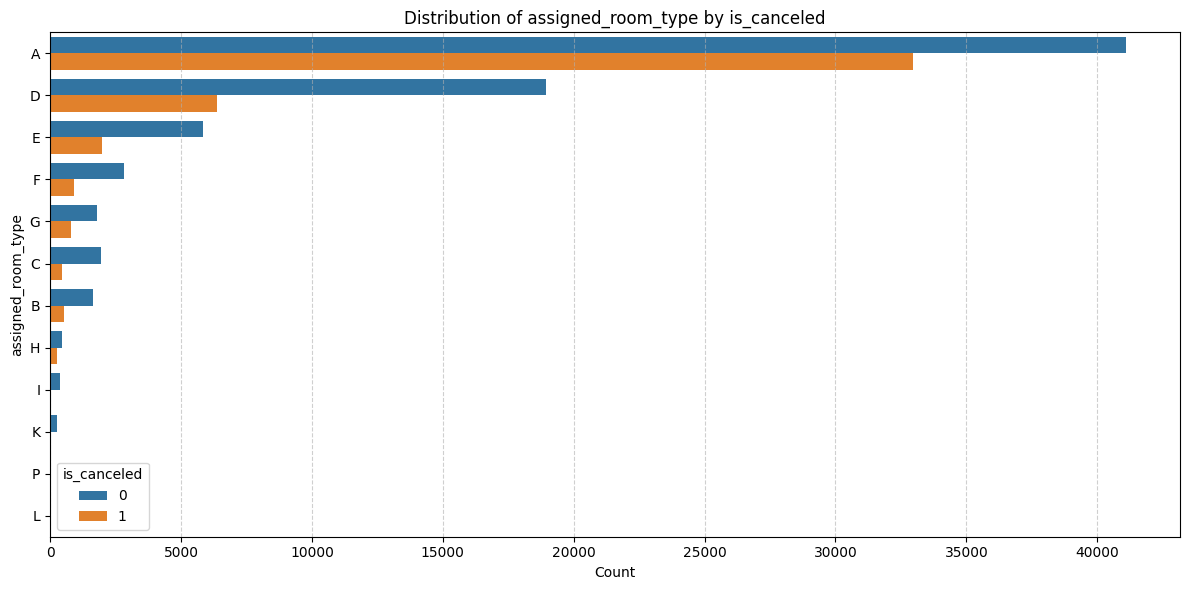

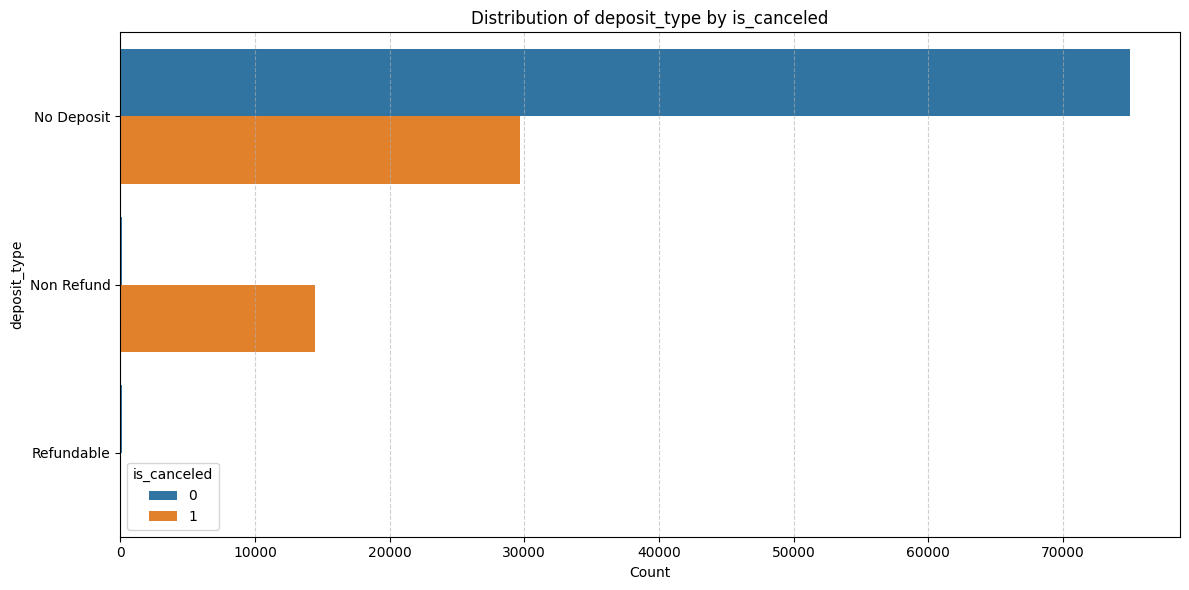

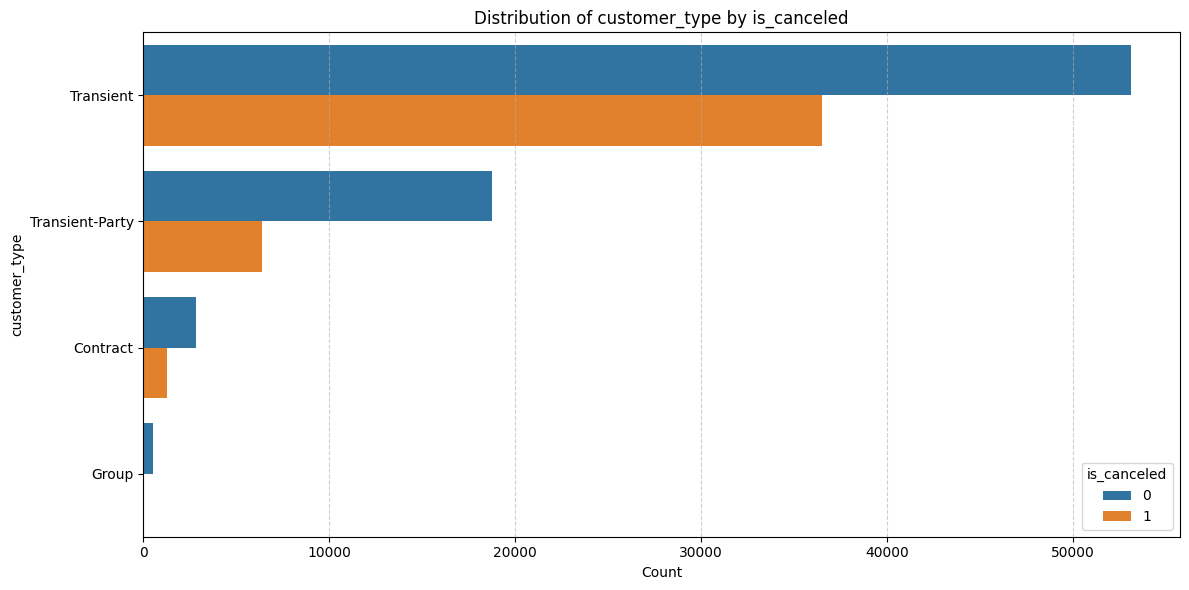

In [16]:
# Categorical relationship analysis.
# Post-outcome fields are excluded because they directly describe the cancellation outcome.
categorical_vars_for_analysis = [
    v for v in categorical_vars
    if v not in ['reservation_status', 'reservation_status_date']
]

for var in categorical_vars_for_analysis:
    plt.figure(figsize=(12, 6))
    sns.countplot(data=df, y=var, hue=target_variable, order=df[var].value_counts().index)
    plt.title(f'Distribution of {var} by is_canceled')
    plt.xlabel('Count')
    plt.ylabel(var)
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

## 10. Data Preprocessing and Feature Engineering

### Feature Engineering: Arrival Date

The hotel dataset already stores arrival year, month and day separately. To follow the reference notebook's date-feature approach, these fields are combined into an arrival date and then represented again as numerical date components. The original text month is not retained as a modelling field.

In [17]:
month_map = {
    'January':1, 'February':2, 'March':3, 'April':4, 'May':5, 'June':6,
    'July':7, 'August':8, 'September':9, 'October':10, 'November':11, 'December':12
}

df['Arrival_Date'] = pd.to_datetime({
    'year': df['arrival_date_year'],
    'month': df['arrival_date_month'].map(month_map),
    'day': df['arrival_date_day_of_month']
})

df['Arrival_Year'] = df['Arrival_Date'].dt.year
df['Arrival_Month'] = df['Arrival_Date'].dt.month
df['Arrival_Day'] = df['Arrival_Date'].dt.day

df = df.drop(columns=['Arrival_Date', 'arrival_date_year', 'arrival_date_month', 'arrival_date_day_of_month'])

print('New date features created: Arrival_Year, Arrival_Month, Arrival_Day')
display(df[['Arrival_Year','Arrival_Month','Arrival_Day']].head())

New date features created: Arrival_Year, Arrival_Month, Arrival_Day


,Arrival_Year,Arrival_Month,Arrival_Day
0,2015,7,1
1,2015,7,1
2,2015,7,1
3,2015,7,1
4,2015,7,1


### Encoding Categorical Variables

One-hot encoding is applied with `drop_first=True`, following the reference notebook's approach.

In [18]:
# Post-outcome variables are not predictors of cancellation and are excluded from modelling.
# Agent and company are administrative identifiers, analogous to the ID field in the reference assignment.
# They are also excluded from the model.

leakage_or_identifier_cols = ['reservation_status', 'reservation_status_date', 'agent', 'company']

# Keep a copy for modelling before encoding
df_model = df.copy()
df_model = df_model.drop(columns=[c for c in leakage_or_identifier_cols if c in df_model.columns])

# Separate target
y = df_model[target_variable].astype(int)
X_raw = df_model.drop(columns=[target_variable])

# Identify categorical columns
categorical_cols = X_raw.select_dtypes(include=['object', 'category']).columns.tolist()
print('Categorical columns to be one-hot encoded:')
print(categorical_cols)

# Fill missing categorical values using the most frequent category, as a missing-value safeguard.
for col in categorical_cols:
    if X_raw[col].isnull().any():
        X_raw[col] = X_raw[col].fillna(X_raw[col].mode(dropna=True)[0])

# One-hot encoding
df_encoded = pd.get_dummies(X_raw, columns=categorical_cols, drop_first=True, dtype=int)
print('Shape after one-hot encoding:', df_encoded.shape)
display(df_encoded.head())

Categorical columns to be one-hot encoded:
['hotel', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']
Shape after one-hot encoding: (119390, 235)


,lead_time,arrival_date_week_number,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,...,assigned_room_type_H,assigned_room_type_I,assigned_room_type_K,assigned_room_type_L,assigned_room_type_P,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Group,customer_type_Transient,customer_type_Transient-Party
0,342,27,0,0,2,0.0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,737,27,0,0,2,0.0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,7,27,0,1,1,0.0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,13,27,0,1,1,0.0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,14,27,0,2,2,0.0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


### Missing-Value Safeguard for Numerical Variables

In [19]:
# Median imputation for numerical variables, following the reference assignment's preprocessing safeguard.
numerical_feature_cols = df_encoded.select_dtypes(include=np.number).columns.tolist()
for col in numerical_feature_cols:
    if df_encoded[col].isnull().any():
        df_encoded[col] = df_encoded[col].fillna(df_encoded[col].median())

print('Remaining missing values after preprocessing:', int(df_encoded.isnull().sum().sum()))

Remaining missing values after preprocessing: 0


### Scaling Numerical Variables

In [20]:
from sklearn.preprocessing import StandardScaler

X = df_encoded.copy()

# Scale numerical predictors, as in the reference notebook.
numerical_cols_for_scaling = X.select_dtypes(include=np.number).columns.tolist()

scaler = StandardScaler()
X[numerical_cols_for_scaling] = scaler.fit_transform(X[numerical_cols_for_scaling])

print('Numerical columns scaled:', len(numerical_cols_for_scaling))
display(X[numerical_cols_for_scaling].describe().T.head(15))

Numerical columns scaled: 235


,count,mean,std,min,25%,50%,75%,max
lead_time,119390.0,6.094277e-17,1.000004,-0.973319,-0.804878,-0.327630,0.523930,5.923385
arrival_date_week_number,119390.0,-1.295034e-16,1.000004,-1.923191,-0.820662,0.061361,0.796381,1.898910
stays_in_weekend_nights,119390.0,1.197430e-16,1.000004,-0.928890,-0.928890,0.072502,1.073895,18.097569
stays_in_week_nights,119390.0,-2.761469e-17,1.000004,-1.310240,-0.786207,-0.262174,0.261858,24.891398
adults,119390.0,3.237585e-17,1.000004,-3.204792,0.247897,0.247897,0.247897,91.744169
children,119390.0,-3.999369e-17,1.000004,-0.260659,-0.260659,-0.260659,-0.260659,24.830072
babies,119390.0,2.047296e-17,1.000004,-0.081579,-0.081579,-0.081579,-0.081579,102.550120
is_repeated_guest,119390.0,9.522308e-18,1.000004,-0.181560,-0.181560,-0.181560,-0.181560,5.507809
previous_cancellations,119390.0,-3.142362e-17,1.000004,-0.103180,-0.103180,-0.103180,-0.103180,30.690364
previous_bookings_not_canceled,119390.0,2.047296e-17,1.000004,-0.091555,-0.091555,-0.091555,-0.091555,47.990808


## 11. Addressing Class Imbalance with SMOTE

In [21]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print('Original class distribution:', Counter(y))

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print('Resampled class distribution:', Counter(y_resampled))
print('Shape of X_resampled:', X_resampled.shape)
print('Shape of y_resampled:', y_resampled.shape)

Original class distribution: Counter({0: 75166, 1: 44224})
Resampled class distribution: Counter({0: 75166, 1: 75166})
Shape of X_resampled: (150332, 235)
Shape of y_resampled: (150332,)


### Encoding Strategy Review

In [22]:
print('Target values:', sorted(y_resampled.unique()))
print('Target class distribution after SMOTE:')
display(y_resampled.value_counts().sort_index().to_frame('Count'))

print('Feature matrix shape before feature selection:', X_resampled.shape)

Target values: [np.int64(0), np.int64(1)]
Target class distribution after SMOTE:


,Count
is_canceled,
0,75166
1,75166


Feature matrix shape before feature selection: (150332, 235)


## 12. Feature Selection and Multicollinearity Assessment

Following the reference assignment, administrative identifiers and variables that can leak the outcome or represent post-outcome information are excluded. The remaining variables are retained for modelling.

In [23]:
# Remove administrative/post-outcome fields if present.
# reservation_status and reservation_status_date were already removed before encoding.
# agent and company were also removed because they are administrative identifiers.

remove_cols = [c for c in ['ID', 'agent', 'company', 'reservation_status', 'reservation_status_date'] if c in X_resampled.columns]
if remove_cols:
    X_resampled = X_resampled.drop(columns=remove_cols)

print('Columns removed during feature selection:', remove_cols if remove_cols else 'None remaining to remove')
print('Updated feature matrix shape:', X_resampled.shape)

Columns removed during feature selection: None remaining to remove
Updated feature matrix shape: (150332, 235)


## 13. Logistic Regression

X_train: (105232, 235) X_test: (45100, 235)
Training class distribution: {0: 52616, 1: 52616}
Testing class distribution: {0: 22550, 1: 22550}
Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,18732,3818
Actual 1,4790,17760


Classification Report:
              precision    recall  f1-score   support

Not Canceled       0.80      0.83      0.81     22550
    Canceled       0.82      0.79      0.80     22550

    accuracy                           0.81     45100
   macro avg       0.81      0.81      0.81     45100
weighted avg       0.81      0.81      0.81     45100

ROC-AUC Score: 0.8995


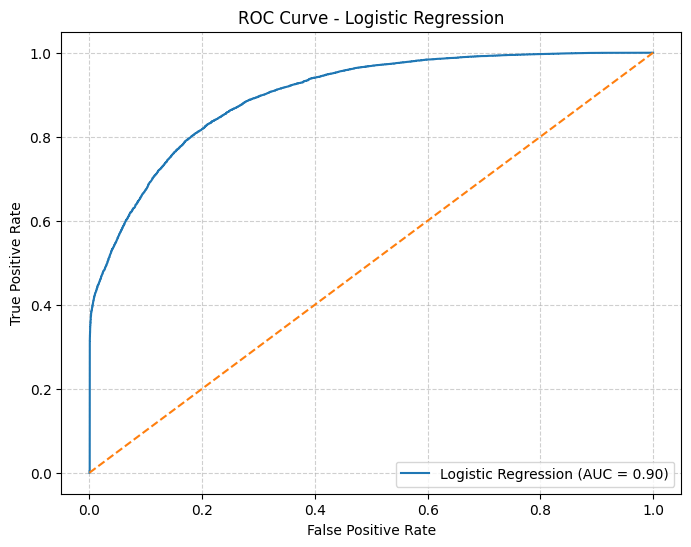

Top 10 influential variables by absolute coefficient:


,Feature,Coefficient,Absolute_Coefficient
13,required_car_parking_spaces,-2.246789,2.246789
8,previous_cancellations,2.031081,2.031081
230,deposit_type_Non Refund,1.553176,1.553176
204,market_segment_Online TA,0.779364,0.779364
157,country_PRT,0.689570,0.689570
9,previous_bookings_not_canceled,-0.671189,0.671189
14,total_of_special_requests,-0.639135,0.639135
221,assigned_room_type_D,-0.604072,0.604072
222,assigned_room_type_E,-0.550924,0.550924
0,lead_time,0.533898,0.533898


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.30, random_state=42, stratify=y_resampled
)

print('X_train:', X_train.shape, 'X_test:', X_test.shape)
print('Training class distribution:', y_train.value_counts().to_dict())
print('Testing class distribution:', y_test.value_counts().to_dict())

log_reg_model = LogisticRegression(solver='lbfgs', random_state=42, max_iter=1000)
log_reg_model.fit(X_train, y_train)

y_pred = log_reg_model.predict(X_test)
y_prob = log_reg_model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
display(pd.DataFrame(cm, index=['Actual 0','Actual 1'], columns=['Predicted 0','Predicted 1']))

print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Not Canceled','Canceled']))

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc_lr = auc(fpr, tpr)
print(f'ROC-AUC Score: {roc_auc_lr:.4f}')

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')
plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

coefficients = log_reg_model.coef_[0]
feature_importance_lr = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': coefficients,
    'Absolute_Coefficient': np.abs(coefficients)
}).sort_values('Absolute_Coefficient', ascending=False)

print('Top 10 influential variables by absolute coefficient:')
display(feature_importance_lr.head(10))

## 14. Decision Tree

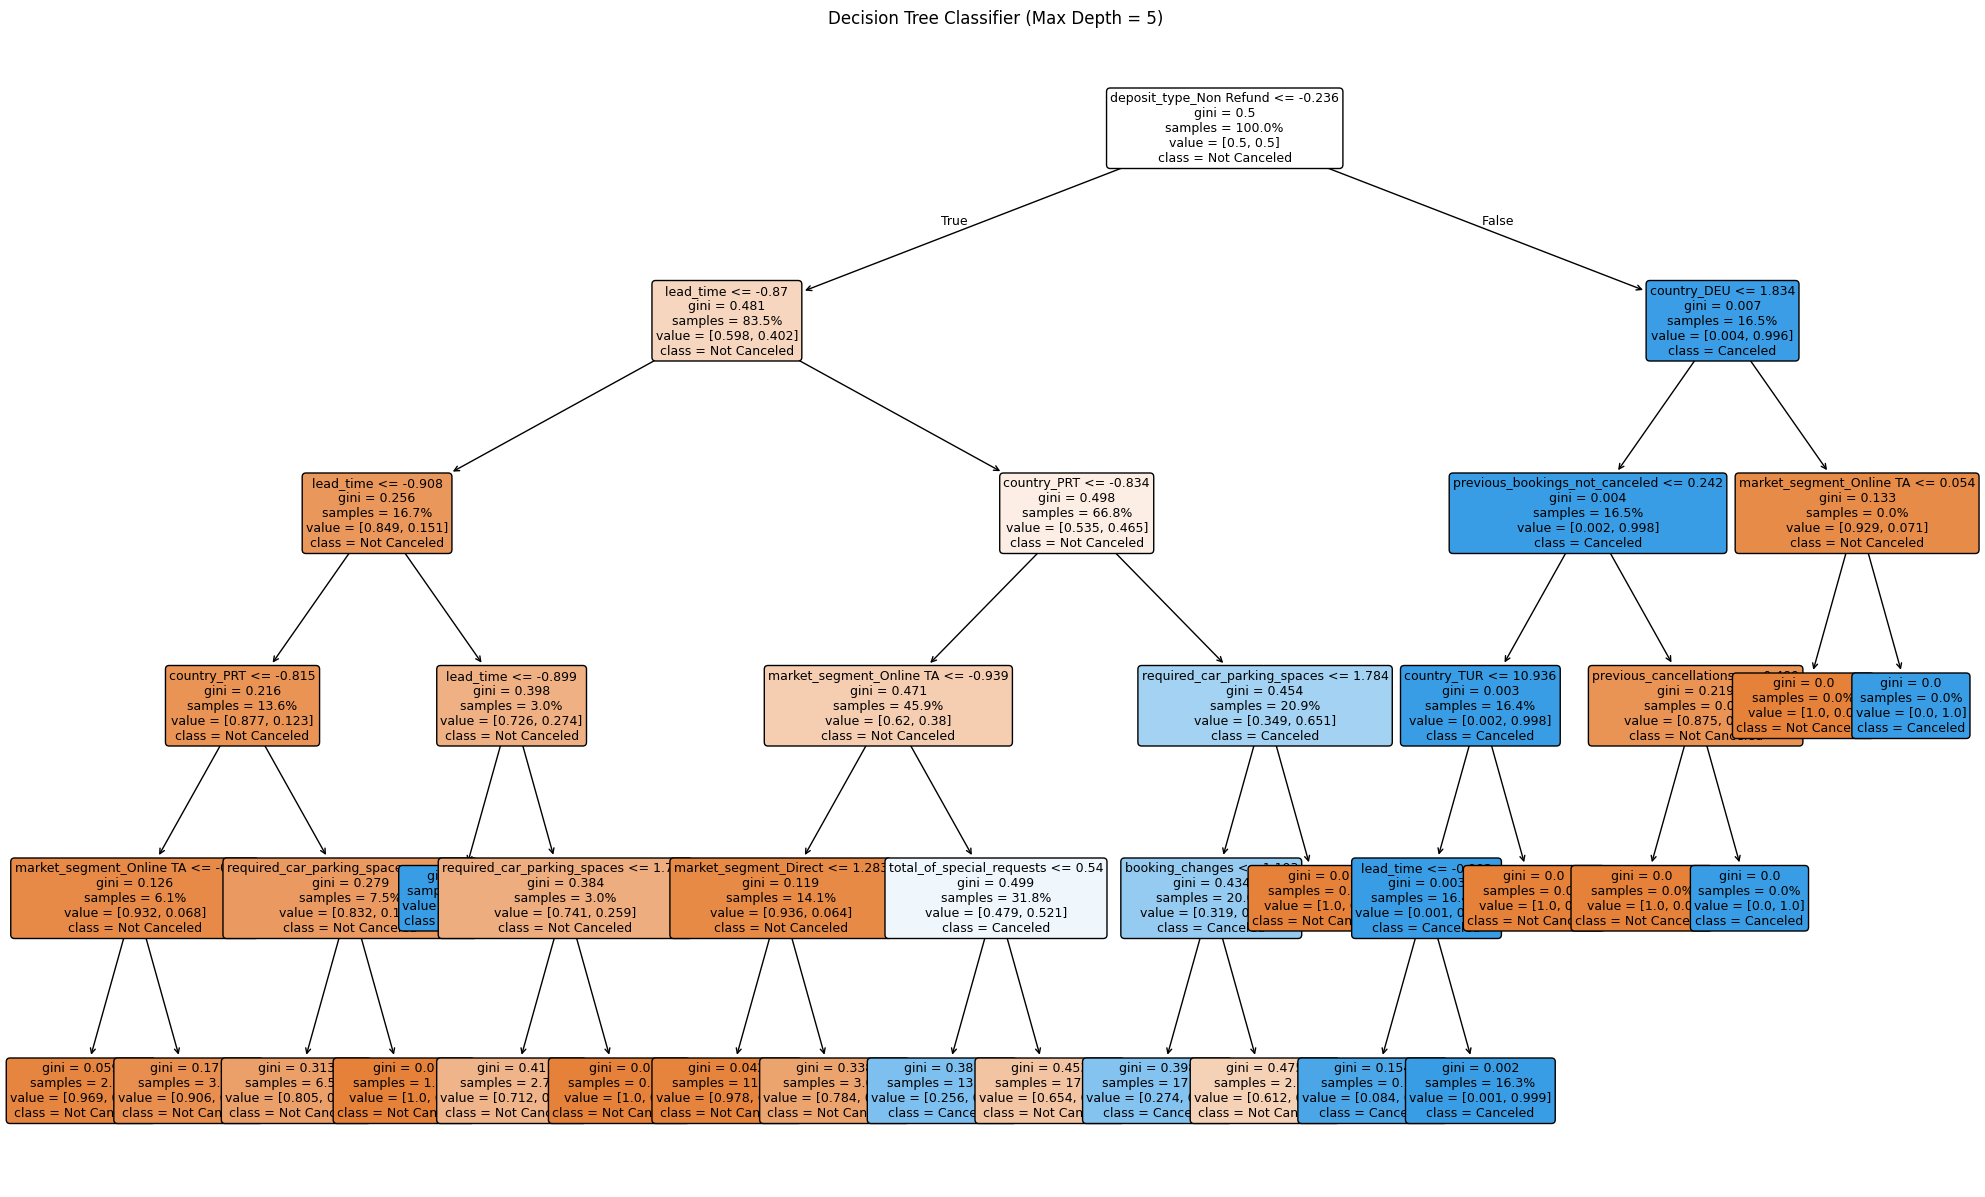

Top 10 Decision Tree features:


,Feature,Importance
230,deposit_type_Non Refund,0.422653
204,market_segment_Online TA,0.178154
0,lead_time,0.122456
14,total_of_special_requests,0.107935
157,country_PRT,0.094602
13,required_car_parking_spaces,0.040679
10,booking_changes,0.022897
201,market_segment_Direct,0.007819
65,country_DEU,0.001982
9,previous_bookings_not_canceled,0.000504


Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,18870,3680
Actual 1,4800,17750


Classification Report:
              precision    recall  f1-score   support

Not Canceled       0.80      0.84      0.82     22550
    Canceled       0.83      0.79      0.81     22550

    accuracy                           0.81     45100
   macro avg       0.81      0.81      0.81     45100
weighted avg       0.81      0.81      0.81     45100

ROC-AUC Score: 0.8820


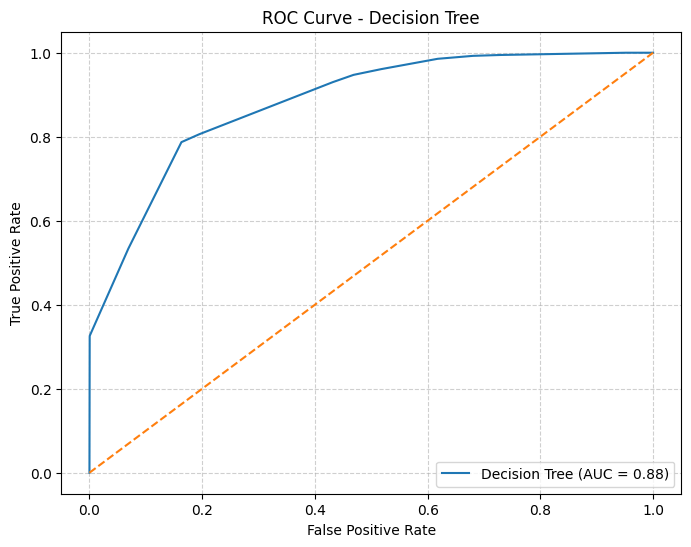

In [25]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

dt_classifier = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_classifier.fit(X_train, y_train)

y_pred_dt = dt_classifier.predict(X_test)
y_prob_dt = dt_classifier.predict_proba(X_test)[:, 1]

plt.figure(figsize=(25, 15))
plot_tree(
    dt_classifier,
    feature_names=X_train.columns.tolist(),
    class_names=['Not Canceled','Canceled'],
    filled=True, rounded=True, fontsize=9, proportion=True
)
plt.title('Decision Tree Classifier (Max Depth = 5)')
plt.show()

feature_importance_dt = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': dt_classifier.feature_importances_
}).sort_values('Importance', ascending=False)
print('Top 10 Decision Tree features:')
display(feature_importance_dt.head(10))

cm_dt = confusion_matrix(y_test, y_pred_dt)
print('Confusion Matrix:')
display(pd.DataFrame(cm_dt, index=['Actual 0','Actual 1'], columns=['Predicted 0','Predicted 1']))
print('Classification Report:')
print(classification_report(y_test, y_pred_dt, target_names=['Not Canceled','Canceled']))

fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_prob_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)
print(f'ROC-AUC Score: {roc_auc_dt:.4f}')

plt.figure(figsize=(8,6))
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {roc_auc_dt:.2f})')
plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Decision Tree')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 15. Random Forest

Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,20252,2298
Actual 1,4654,17896


Classification Report:
              precision    recall  f1-score   support

Not Canceled       0.81      0.90      0.85     22550
    Canceled       0.89      0.79      0.84     22550

    accuracy                           0.85     45100
   macro avg       0.85      0.85      0.85     45100
weighted avg       0.85      0.85      0.85     45100

ROC-AUC Score: 0.9316


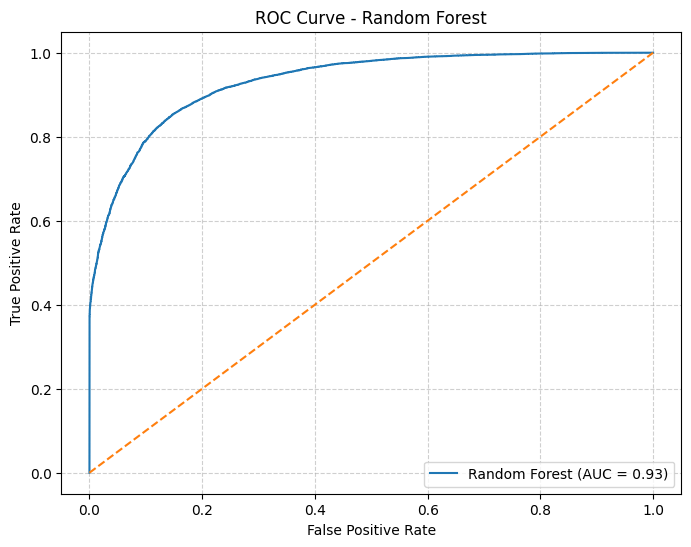

Top 10 Random Forest features:


,Feature,Importance
230,deposit_type_Non Refund,0.156729
0,lead_time,0.107932
157,country_PRT,0.105364
14,total_of_special_requests,0.101042
8,previous_cancellations,0.047450
10,booking_changes,0.047367
13,required_car_parking_spaces,0.043478
233,customer_type_Transient,0.038195
204,market_segment_Online TA,0.035679
202,market_segment_Groups,0.029868


In [26]:
from sklearn.ensemble import RandomForestClassifier

rf_classifier = RandomForestClassifier(
    n_estimators=100, max_depth=10, random_state=42, n_jobs=-1
)
rf_classifier.fit(X_train, y_train)

y_pred_rf = rf_classifier.predict(X_test)
y_prob_rf = rf_classifier.predict_proba(X_test)[:, 1]

cm_rf = confusion_matrix(y_test, y_pred_rf)
print('Confusion Matrix:')
display(pd.DataFrame(cm_rf, index=['Actual 0','Actual 1'], columns=['Predicted 0','Predicted 1']))
print('Classification Report:')
print(classification_report(y_test, y_pred_rf, target_names=['Not Canceled','Canceled']))

fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
print(f'ROC-AUC Score: {roc_auc_rf:.4f}')

plt.figure(figsize=(8,6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

feature_importance_rf = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_classifier.feature_importances_
}).sort_values('Importance', ascending=False)
print('Top 10 Random Forest features:')
display(feature_importance_rf.head(10))

## 16. Model Comparison

Model Comparison Table:


,Accuracy,Precision (Canceled),Recall (Canceled),F1 Score (Canceled),ROC-AUC
Logistic Regression,0.8091,0.8231,0.7876,0.8049,0.8995
Decision Tree,0.8120,0.8283,0.7871,0.8072,0.8820
Random Forest,0.8459,0.8862,0.7936,0.8374,0.9316


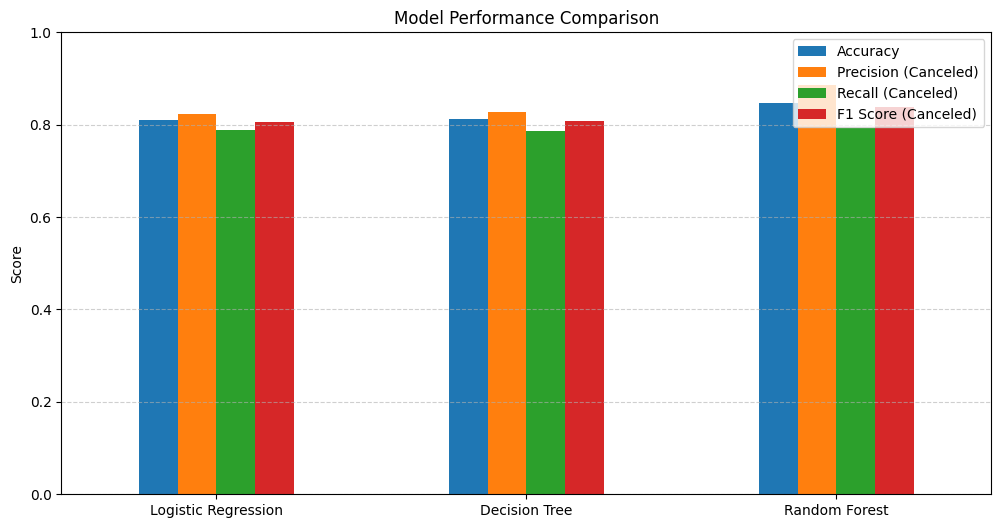

In [27]:
metrics = {
    'Logistic Regression': {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision (Canceled)': precision_score(y_test, y_pred, zero_division=0),
        'Recall (Canceled)': recall_score(y_test, y_pred, zero_division=0),
        'F1 Score (Canceled)': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_lr
    },
    'Decision Tree': {
        'Accuracy': accuracy_score(y_test, y_pred_dt),
        'Precision (Canceled)': precision_score(y_test, y_pred_dt, zero_division=0),
        'Recall (Canceled)': recall_score(y_test, y_pred_dt, zero_division=0),
        'F1 Score (Canceled)': f1_score(y_test, y_pred_dt, zero_division=0),
        'ROC-AUC': roc_auc_dt
    },
    'Random Forest': {
        'Accuracy': accuracy_score(y_test, y_pred_rf),
        'Precision (Canceled)': precision_score(y_test, y_pred_rf, zero_division=0),
        'Recall (Canceled)': recall_score(y_test, y_pred_rf, zero_division=0),
        'F1 Score (Canceled)': f1_score(y_test, y_pred_rf, zero_division=0),
        'ROC-AUC': roc_auc_rf
    }
}

comparison_df = pd.DataFrame(metrics).T
print('Model Comparison Table:')
display(comparison_df.round(4))

comparison_df[['Accuracy','Precision (Canceled)','Recall (Canceled)','F1 Score (Canceled)']].plot(kind='bar', figsize=(12,6))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

## 17. Interpretation of Model Results

Use the generated model comparison table, confusion matrices, ROC-AUC values, Logistic Regression coefficients and tree-based feature-importance tables to interpret the hotel-booking cancellation problem. The positive class is **Canceled (1)**.

The notebook does not hard-code model results; all reported metrics are generated from the student's dataset when the notebook is run.

## 18. Conclusion

This study applies the same core supervised-classification workflow used in the reference Financial Loan assignment to the hotel booking dataset. The analysis covers descriptive statistics, categorical frequency distributions, data-quality checks, outlier detection, correlation analysis, relationship analysis, feature engineering, one-hot encoding, scaling, SMOTE, feature selection, Logistic Regression, Decision Tree, Random Forest and standard classification evaluation measures.

The final model comparison should be based on the actual results produced after running the notebook in Google Colab.